In [12]:
import os
import sys
import glob
import json
import pickle
import datetime
import pandas as pd
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import scipy as sp

sys.path.insert(1, '../utils')

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from utils import *
from mUtils import *
from plotUtils import *

%matplotlib inline
plt.rcParams.update({'font.size': 11})

In [13]:
COLOR_MAP = {
                'mediumblue': "Unstable Focus",
                'darkgreen': "Stable Node",
                'red': "Unstable Saddle Point",
                'saddlebrown': "Stable Spiral",
                'purple': "Unstable Spiral",
                'black': "Circle"
            }

In [14]:
# read parameters from a json file
with open('../params.json', 'r+') as f:
    params = json.load(f)

figureroot = "./results/system_02/fp"
os.makedirs(figureroot, exist_ok=True)

In [15]:
load_dir = "../system_02/results/fp/"
load_str = datetime.datetime(2024, 2, 23)
sub_dir = f"exp-{load_str.year}-{load_str.month}-{load_str.day}"

results_dir = os.path.join(load_dir, sub_dir)
file_paths = glob.glob(os.path.join(results_dir, '*.pkl'))
print(f"Total no. of files = {len(file_paths)}")

Total no. of files = 210


In [16]:
sigValues = np.arange(2.5, 18.5, 2.5)
kValues = np.array([-0.8, -0.2, 0.0, 0.2, 0.8])

iMin = -0.25; iMax = 0.25; iSteps = 500
iValues = iMin + np.arange(0, iSteps + 1) / iSteps * (iMax - iMin)

In [17]:
sigValues

array([ 2.5,  5. ,  7.5, 10. , 12.5, 15. , 17.5])

In [18]:
filePaths = [path for path in file_paths if '_K_' in path]

sE = sigValues[0]

sigmai_lookup = {}
k_lookup = {}

for n, filePath in enumerate(filePaths):
    baseName = os.path.basename(filePath).split('.pkl')[0]
    sige_val = float(baseName.split('_')[3])
    sigi_val = float(baseName.split('_')[4])
    k_val = float(baseName.split('_')[-1])

    # if sige_val != sE:
    #     continue

    if sigi_val not in sigmai_lookup.keys():
        sigmai_lookup[sigi_val] = [filePath]
        k_lookup[sigi_val] = [k_val]
    else:
        sigmai_lookup[sigi_val].append(filePath)
        k_lookup[sigi_val].append(k_val)

for key, vals in k_lookup.items():
    k_vals = np.array(vals)
    ksort = np.argsort(k_vals)

    sigmai_lookup[key] = np.array(sigmai_lookup[key])[ksort]

sigma_vals = np.array(list(sigmai_lookup.keys()))
sigSort = np.argsort(sigma_vals)

filePathsSort = []

for n in sigSort:
    sigma_key = sigma_vals[n]
    filePathsSort += list(sigmai_lookup[sigma_key])

filePathsSort = np.array(filePathsSort)

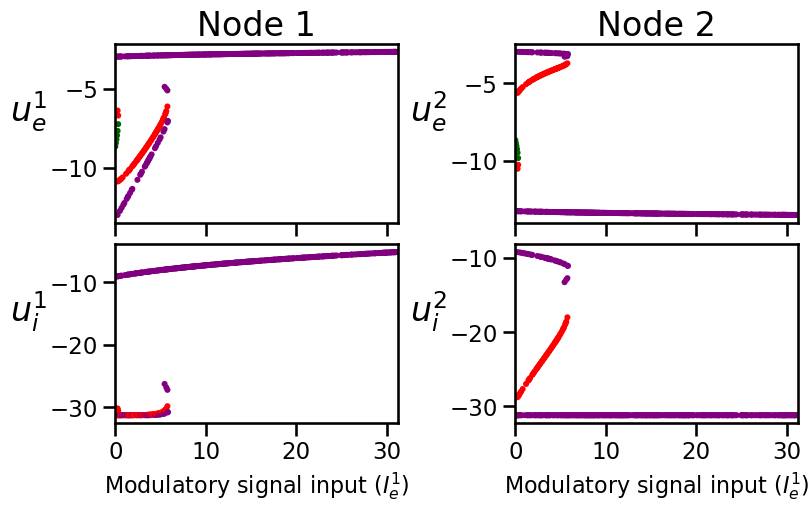

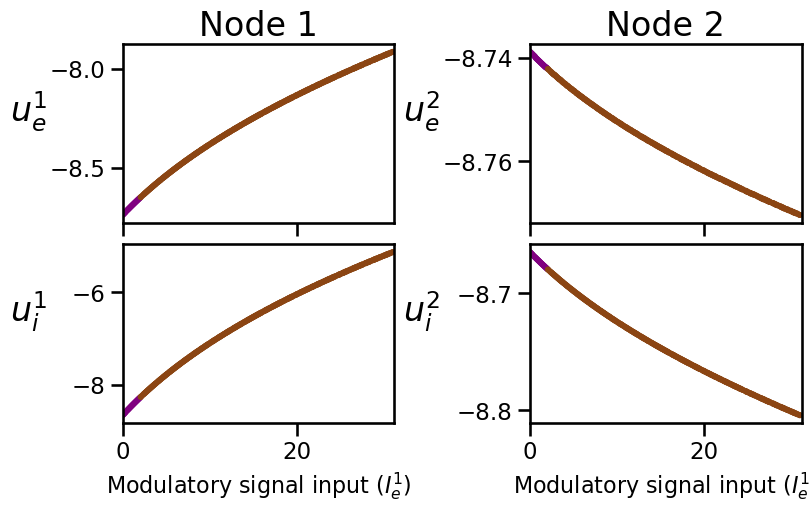

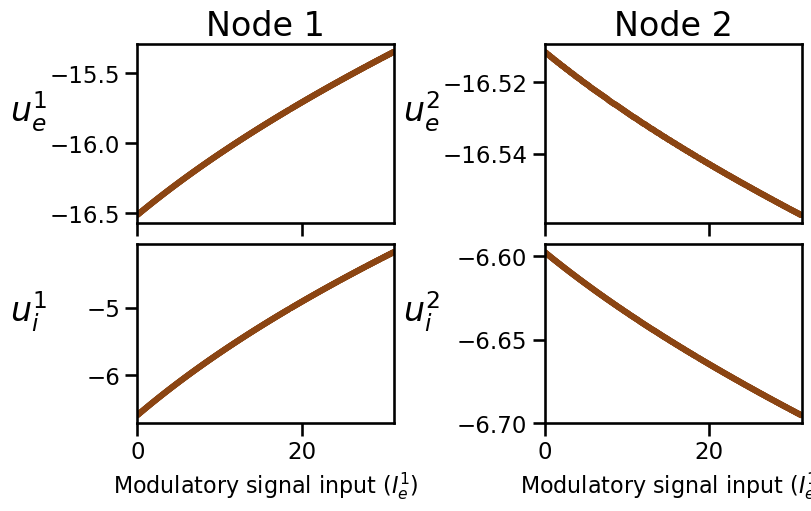

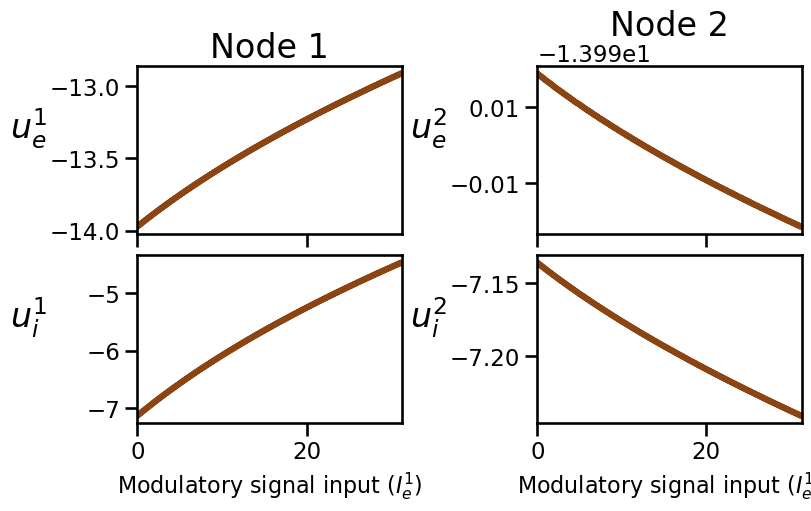

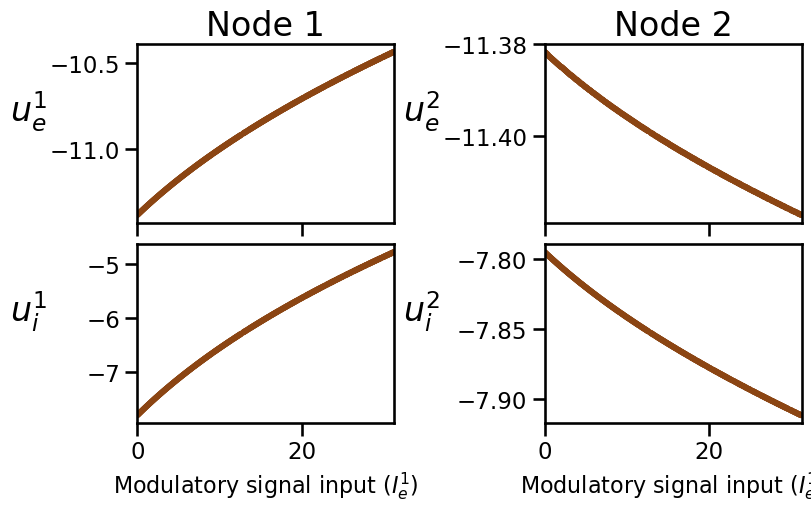

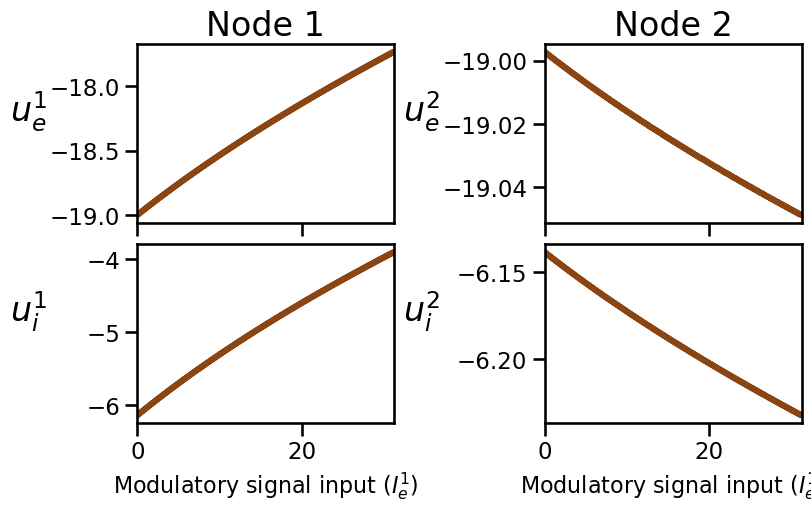

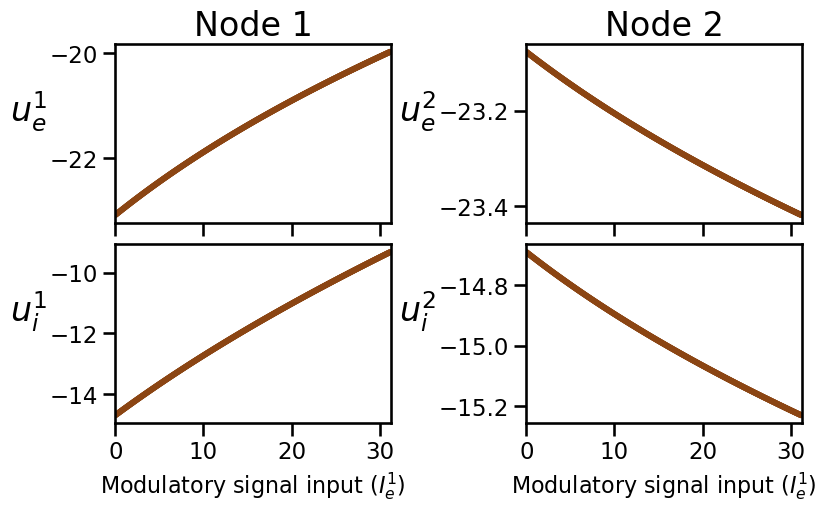

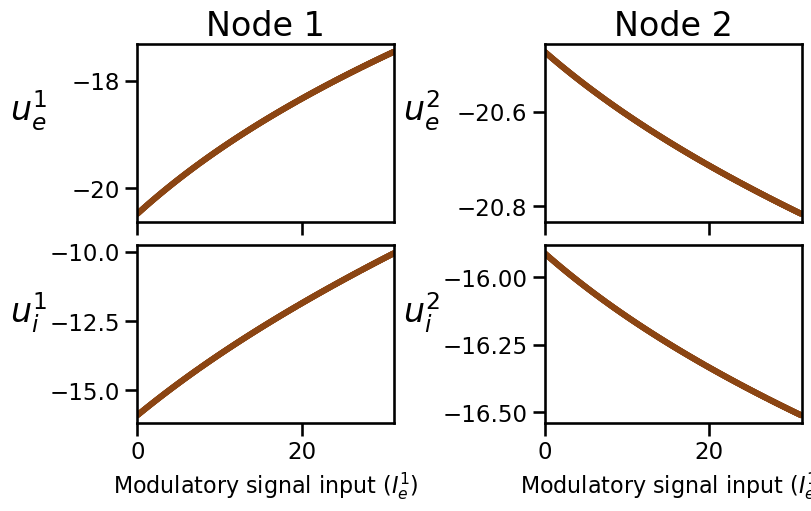

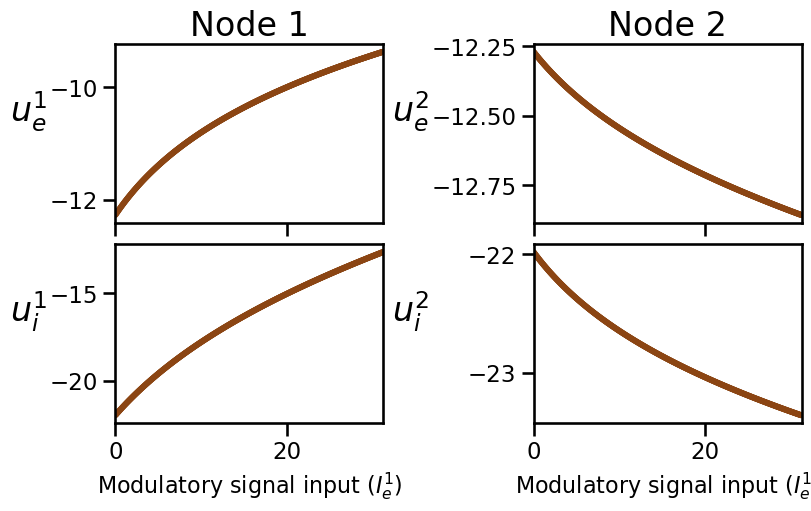

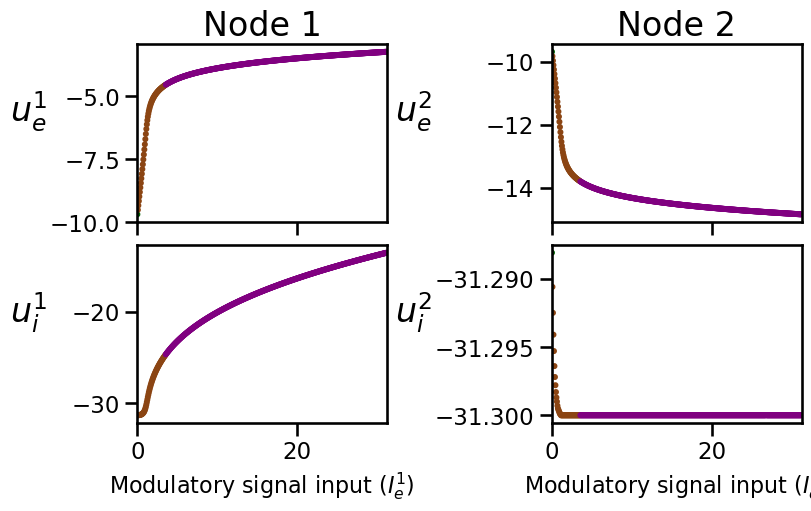

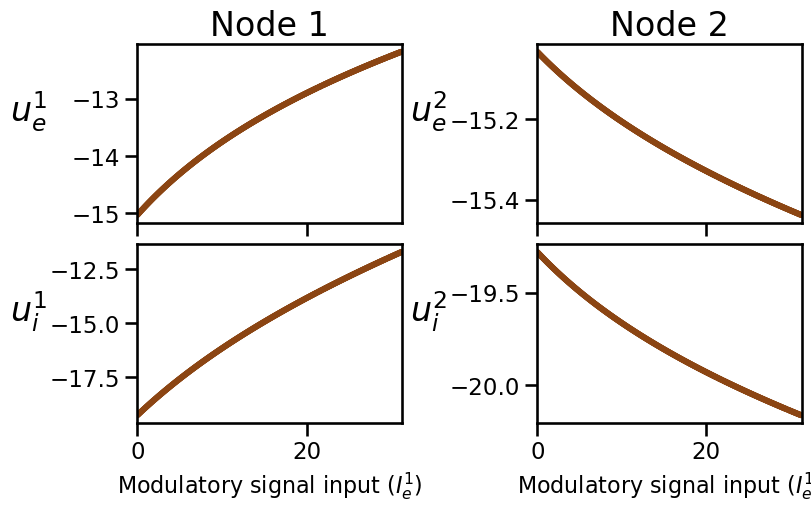

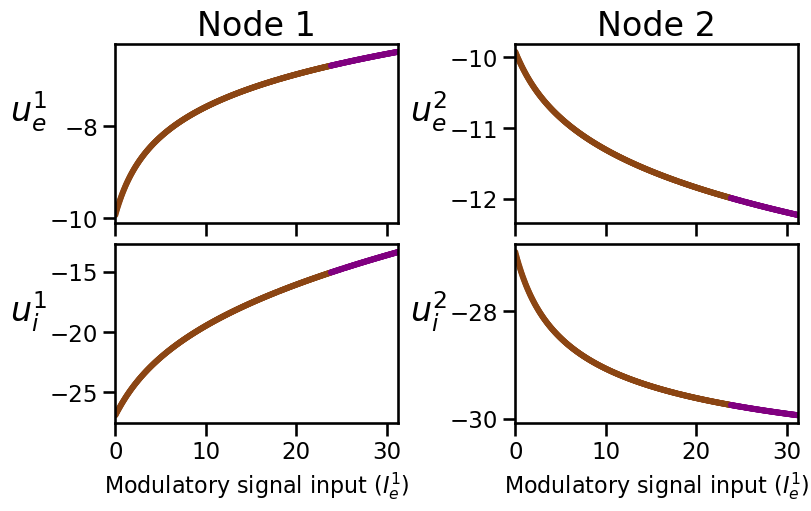

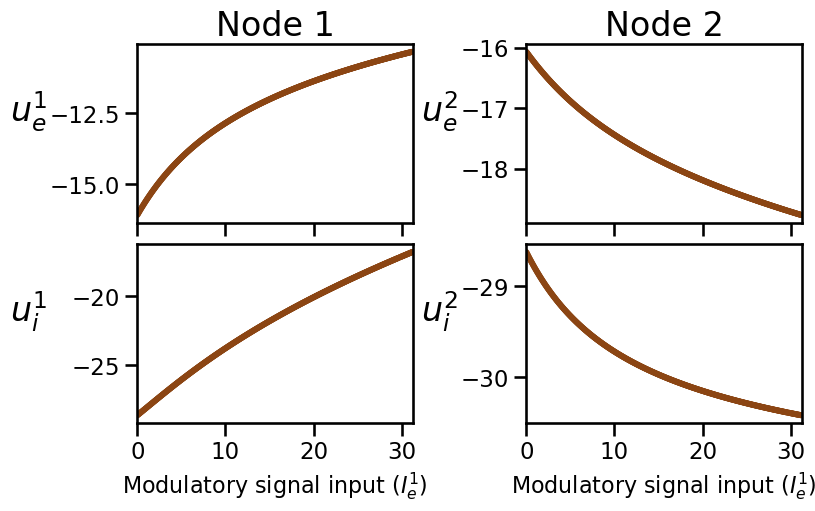

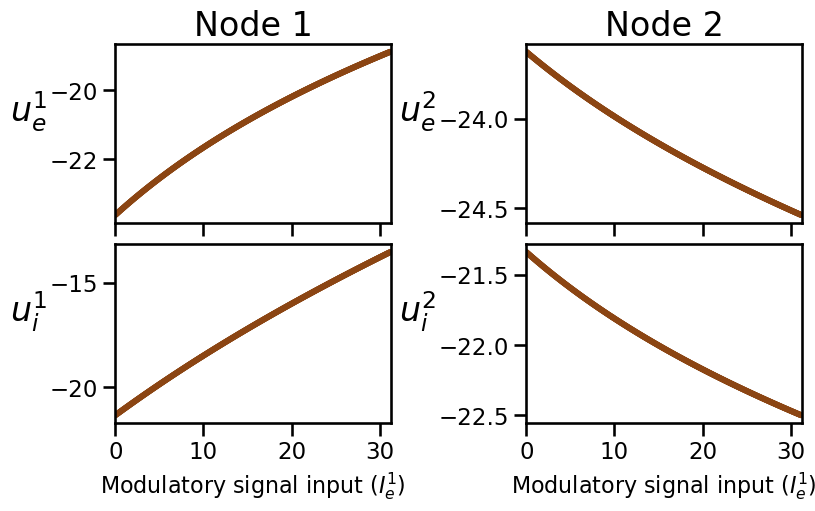

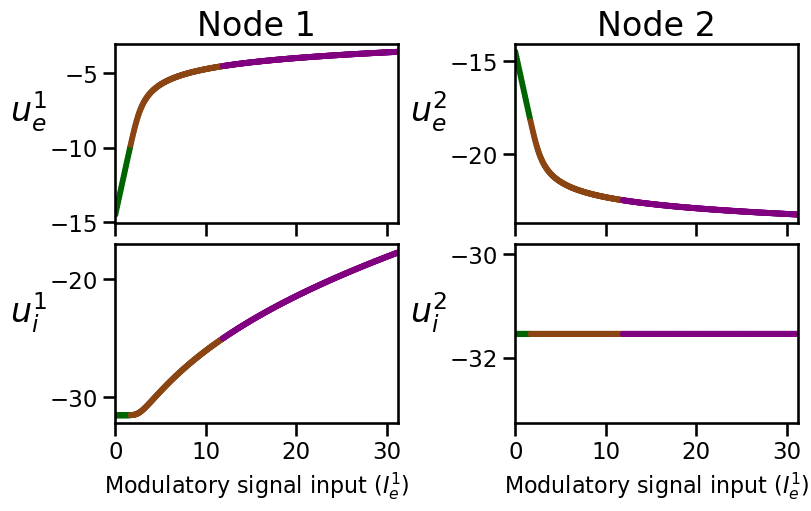

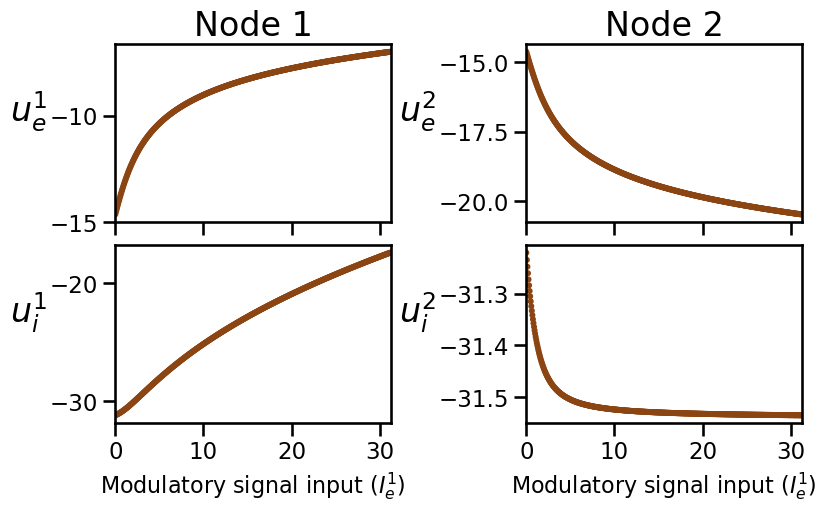

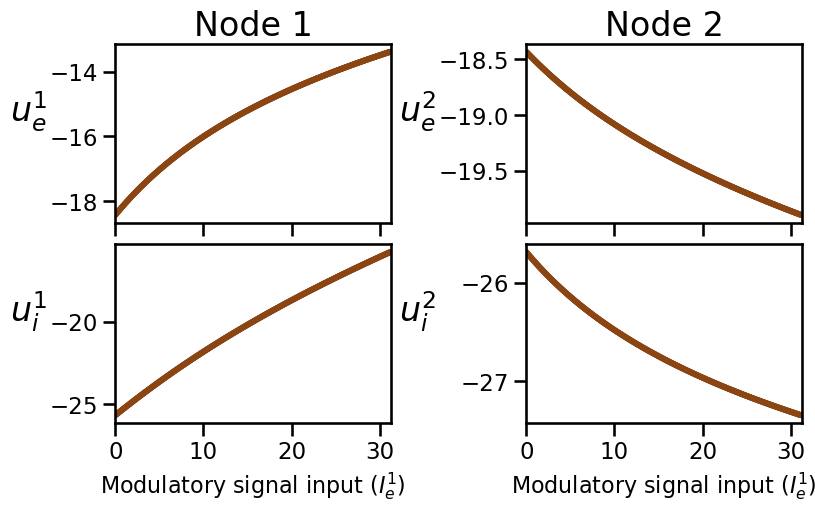

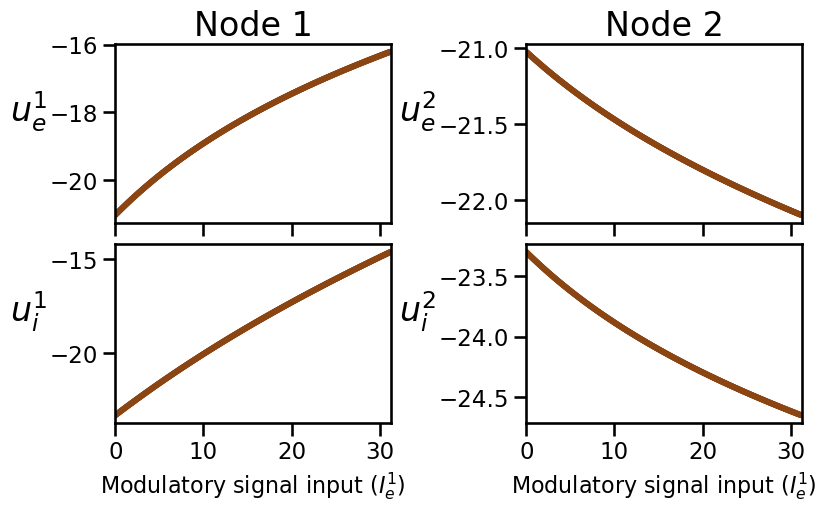

In [19]:
sigiValues = [5, 12.5, 17.5]

for filePath in filePathsSort:
    BaseName = os.path.basename(filePath).split('.pkl')[0]
    K = float(BaseName.split('_')[-1])
    Sige = float(BaseName.split('_')[3])
    Sigi = float(BaseName.split('_')[4])

    if K != -0.8:
        continue
 
    if Sigi not in sigiValues:
        continue
    
    with open(filePath, 'rb') as file_:
        DataDict = pickle.load(file_)
    
    params['sig_e1'] = params['sig_e2'] = Sige
    params['sig_i1'] = params['sig_i2'] = Sigi
    params['K'] = K
    
    plot_dict = {'fig_size': (10, 8), 'xlabel': r"$I^1_e$", 'var_name': 'external stimulus'}
    file_str_k = f"K_{K:.3f}_sige_{Sige:.3f}_sigi_{Sigi:.3f}_expand.jpg"

    fpList = []
    for _, fps in DataDict['fps'].items():
        fpList.append(fps)
    
    fpList = np.array(fpList)
    eig_dict = calc_jacobian(fpList.T, **params)

    eigVals = eig_dict['eigvals']

    I = np.array(DataDict['fp_var']) - params['i_e2']

    for ne, eigSpectrum in enumerate(eigVals):
        signifOrder = np.argsort(eigSpectrum.real)[::-1]
        # adjutsment
        imag_ = eigSpectrum[signifOrder].imag
        imag_ = np.round(imag_, 1)
        if (imag_ == 0).all():
            if DataDict['fp_types']['ue1'][ne] == 'purple':
                DataDict['fp_types']['ue1'][ne] = 'red'
                DataDict['fp_types']['ui1'][ne] = 'red'
                DataDict['fp_types']['ue2'][ne] = 'red'
                DataDict['fp_types']['ui2'][ne] = 'red'
            
            if DataDict['fp_types']['ue1'][ne] == 'saddlebrown':
                DataDict['fp_types']['ue1'][ne] = 'darkgreen'
                DataDict['fp_types']['ui1'][ne] = 'darkgreen'
                DataDict['fp_types']['ue2'][ne] = 'darkgreen'
                DataDict['fp_types']['ui2'][ne] = 'darkgreen'

    fig, axs = plt.subplots(2, 2, figsize=(8, 5), sharex=True, layout='constrained')
    axs[0,0].scatter(I, DataDict['fps']['ue1'], c=DataDict['fp_types']['ue1'], marker='.', s = 32)
    axs[0,0].set_ylabel(r'$u^1_e$', rotation=0, labelpad=15, fontsize=24)
    # axs[0,0].set_ylim(-80, 0)
    axs[0,0].set_title("Node 1", fontsize=24)

    axs[1,0].scatter(I, DataDict['fps']['ui1'], c=DataDict['fp_types']['ui1'], marker='.', s = 32)
    axs[1,0].set_ylabel(r'$u^1_i$', rotation=0, labelpad=15, fontsize=24)
    axs[1,0].set_xlim(0, 31.25)
    axs[1,0].set_xlabel(r"Modulatory signal input $(I^1_e)$", fontsize=16)
    # axs[1,0].set_ylim(-35, 0)

    axs[0,1].scatter(I, DataDict['fps']['ue2'], c=DataDict['fp_types']['ue2'], marker='.', s = 32)
    axs[0,1].set_ylabel(r'$u^2_e$', rotation=0, labelpad=15, fontsize=24)
    axs[0,1].set_title("Node 2", fontsize=24)
    # axs[0,1].set_ylim(-80, 0)

    axs[1,1].scatter(I, DataDict['fps']['ui2'], c=DataDict['fp_types']['ui2'], marker='.', s = 32)
    axs[1,1].set_ylabel(r'$u^2_i$', rotation=0, labelpad=15, fontsize=24)
    axs[1,1].set_xlim(0, 31.25)
    axs[1,1].set_xlabel(r"Modulatory signal input $(I^1_e)$", fontsize=16)
    # axs[1,1].set_ylim(-35, 0)

    fig.align_ylabels() 

    plt.savefig(os.path.join(figureroot, file_str_k), dpi=300, bbox_inches='tight')

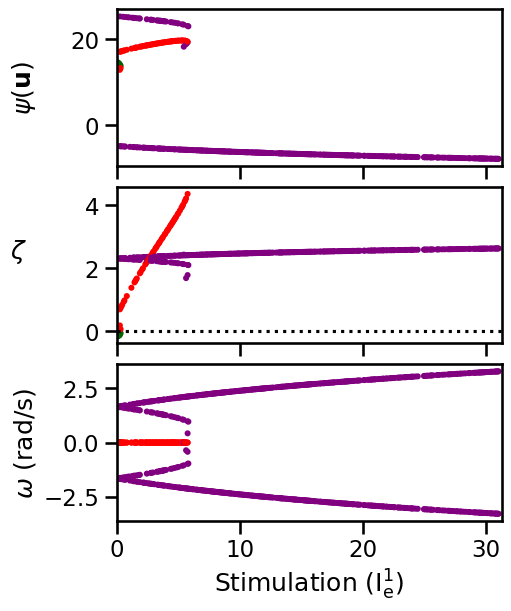

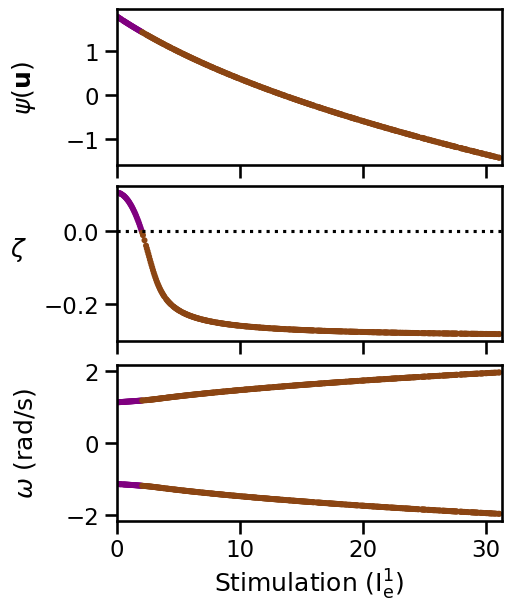

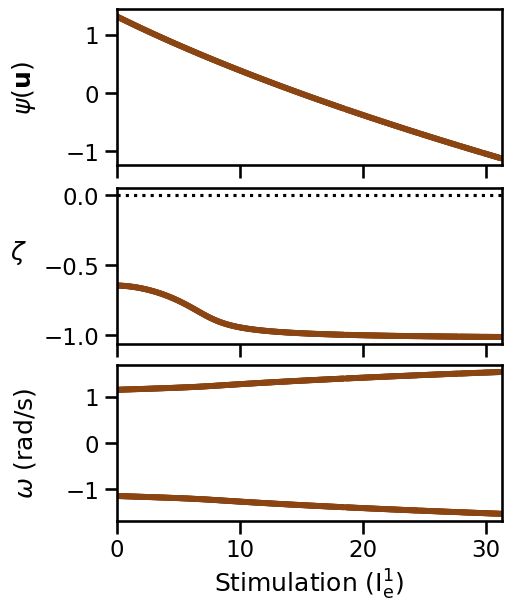

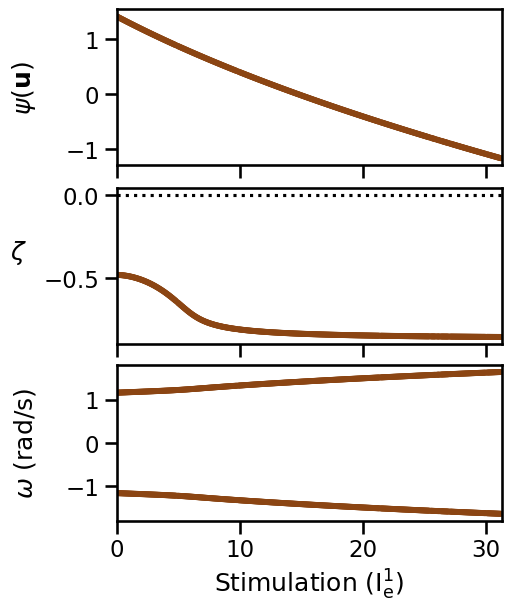

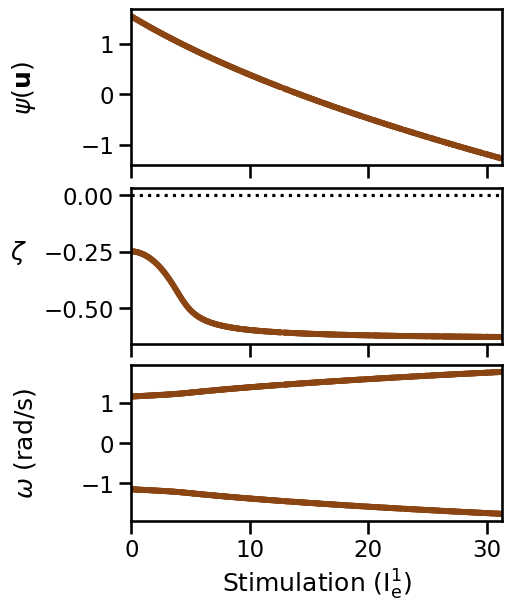

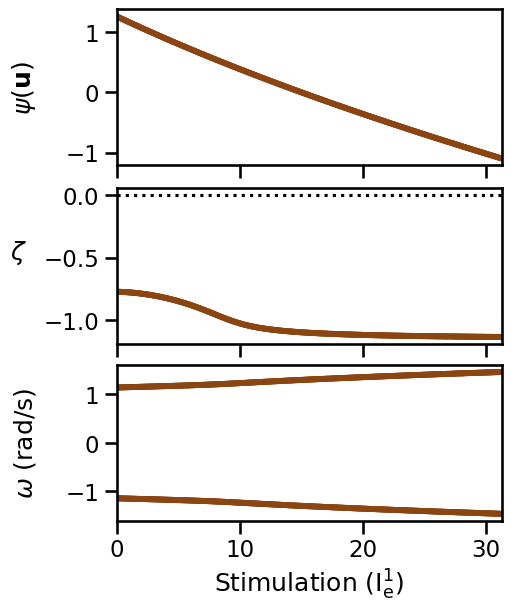

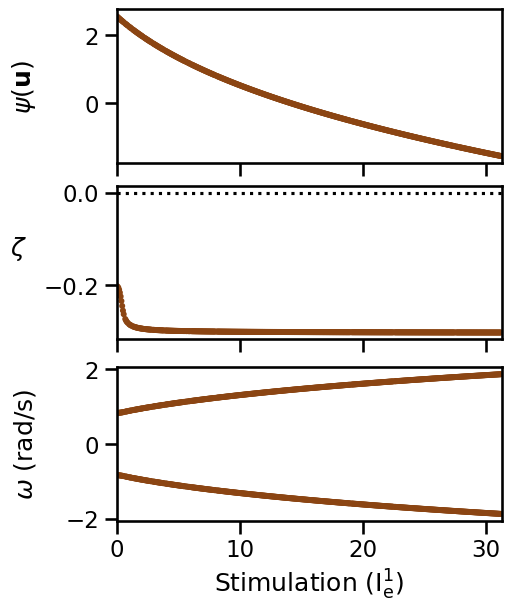

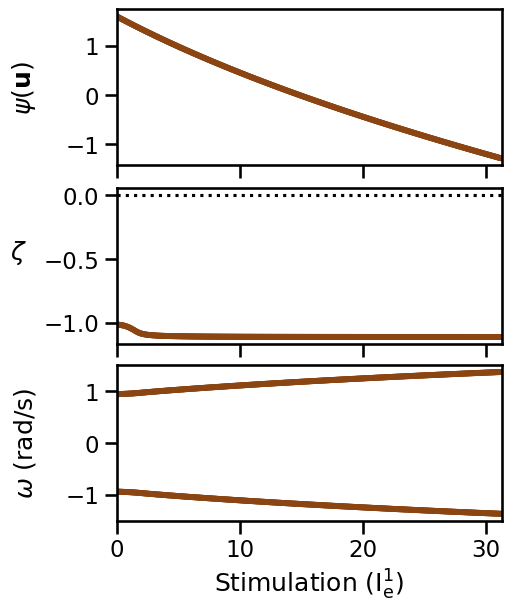

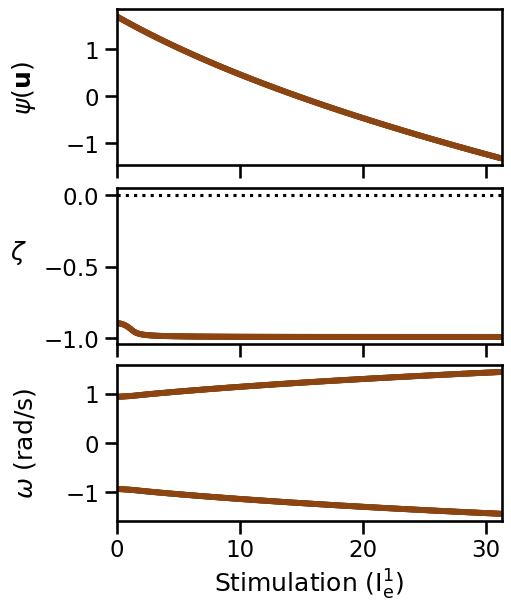

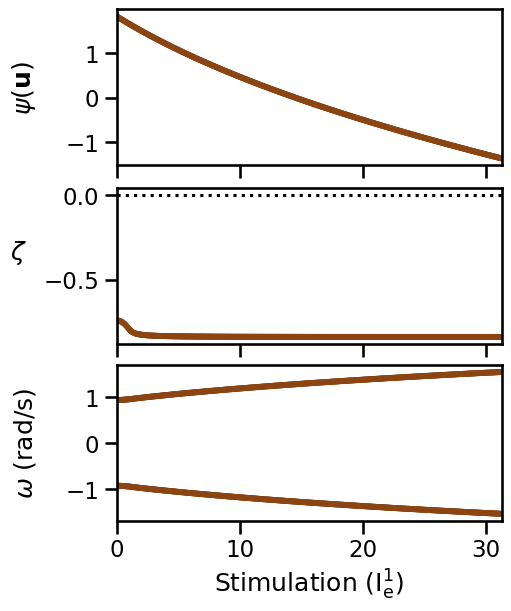

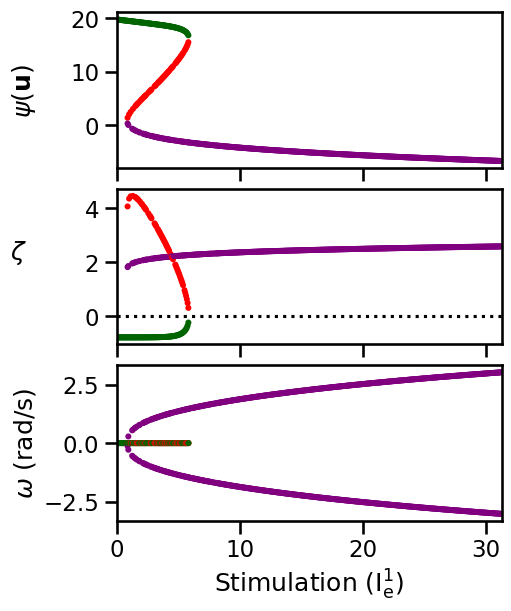

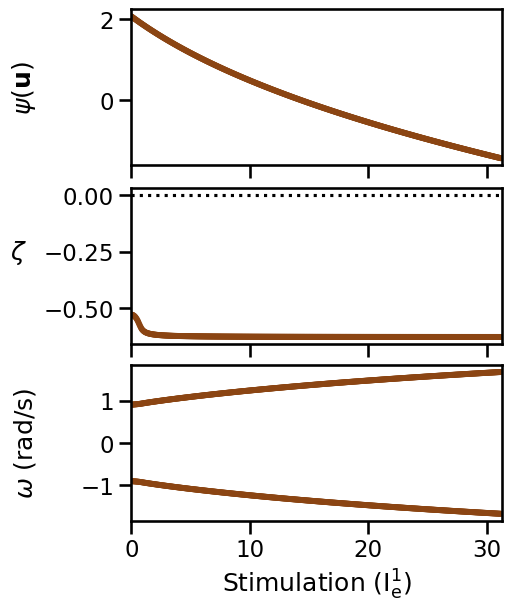

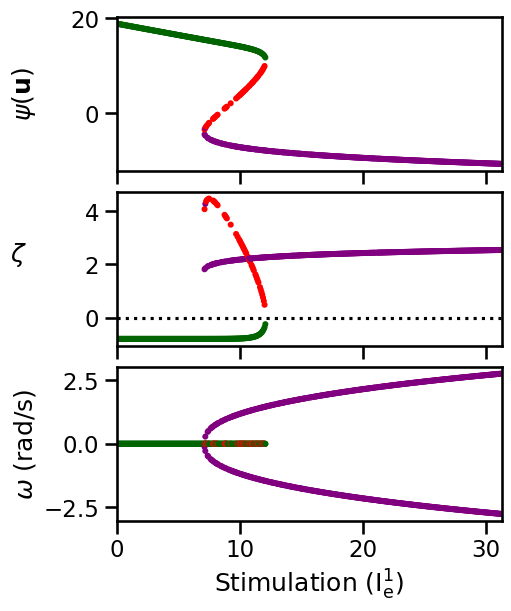

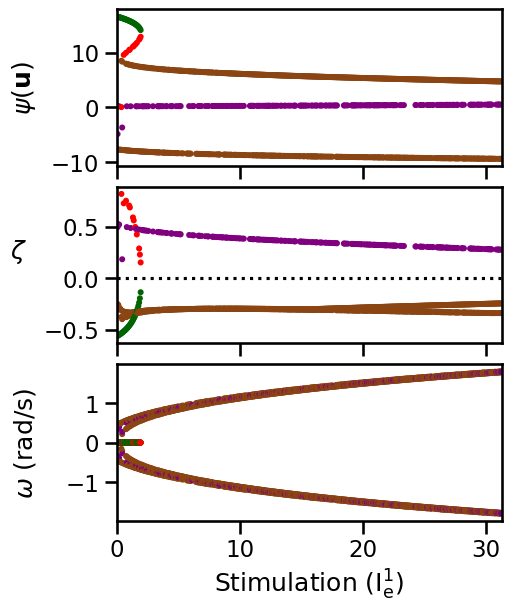

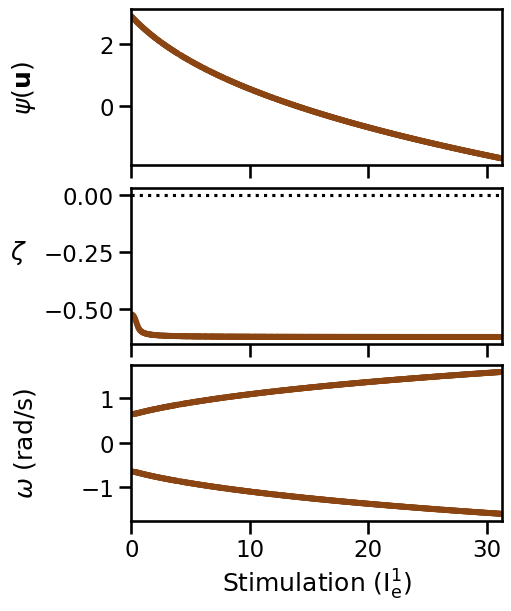

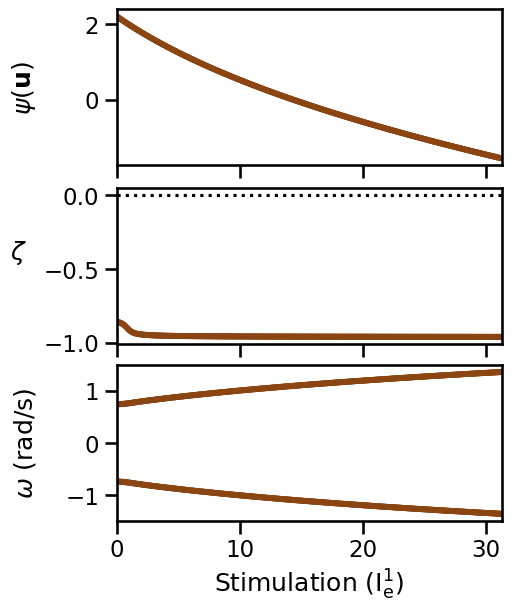

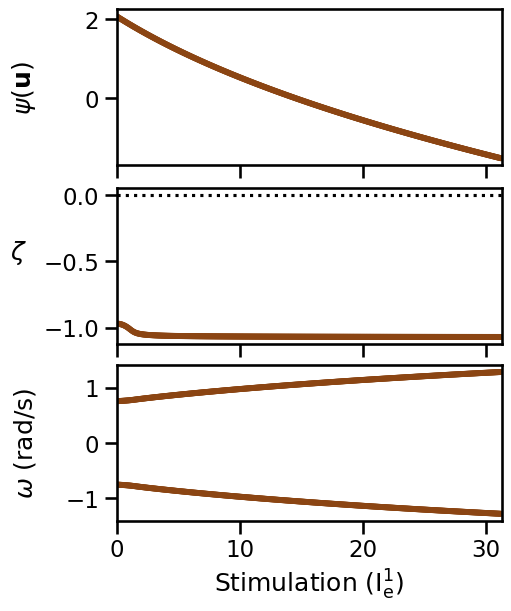

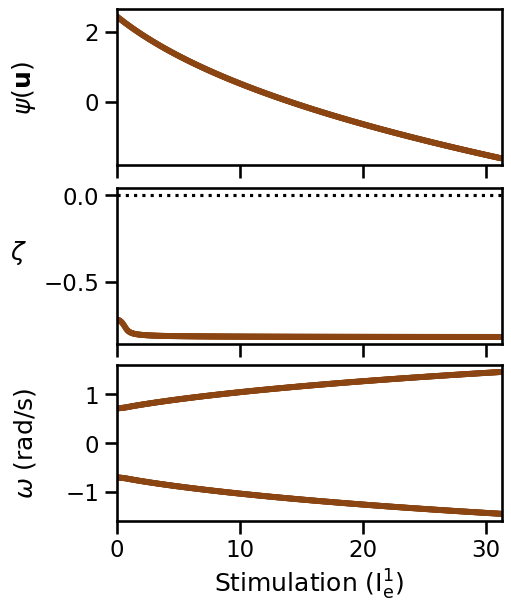

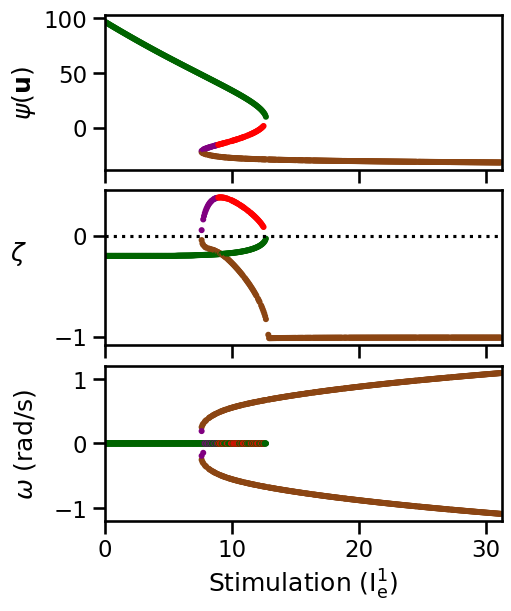

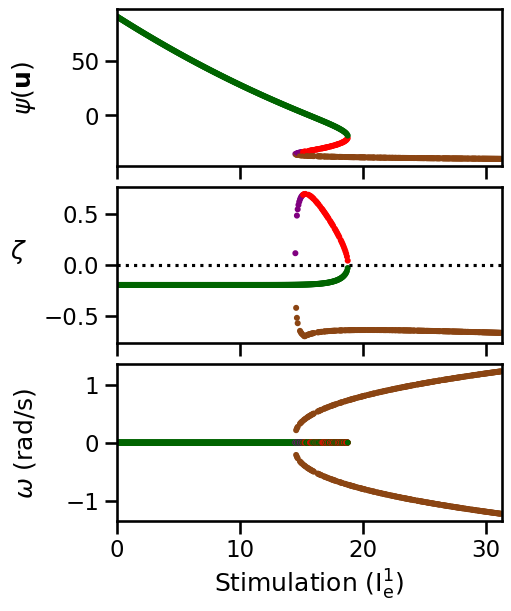

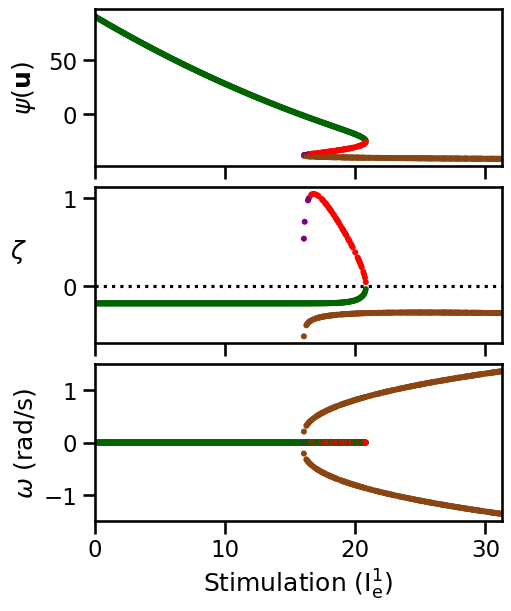

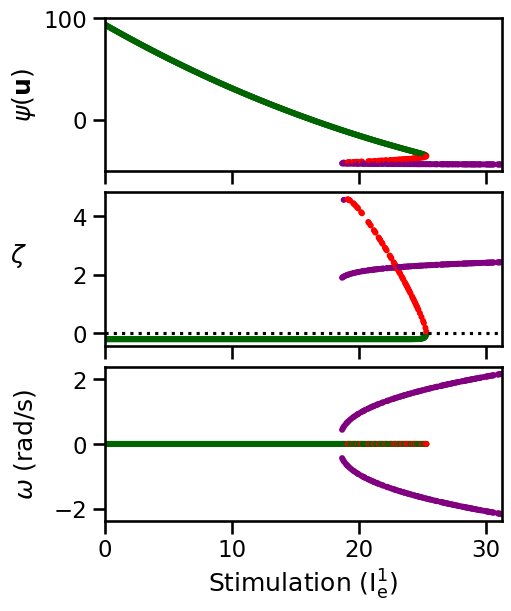

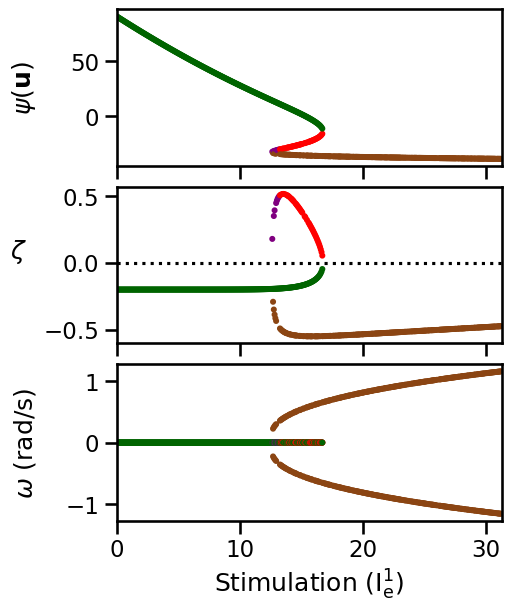

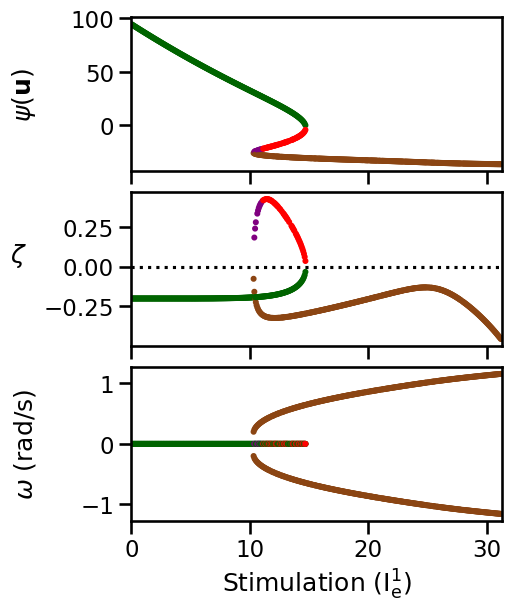

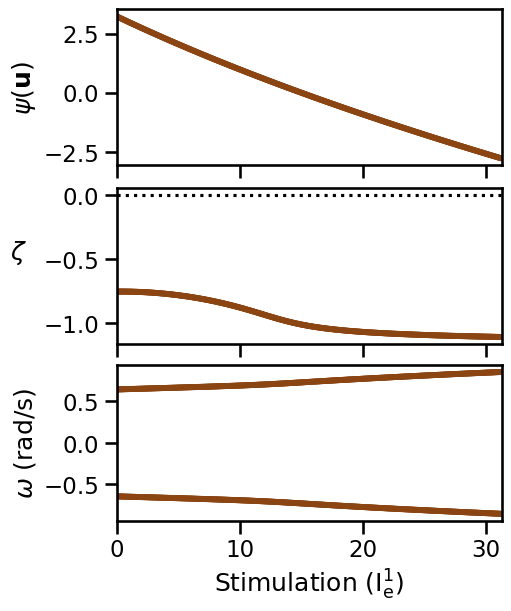

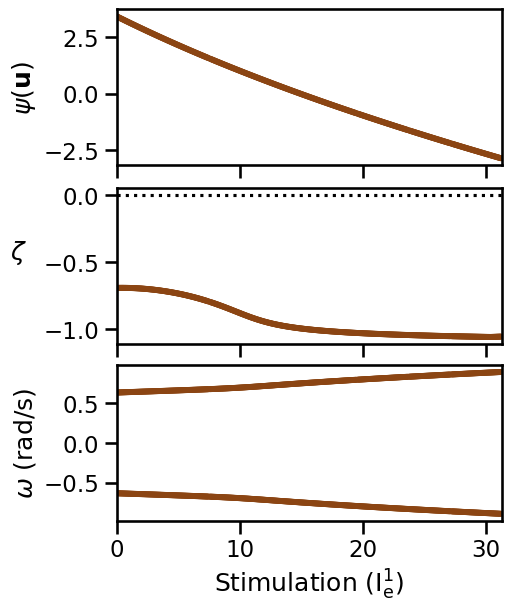

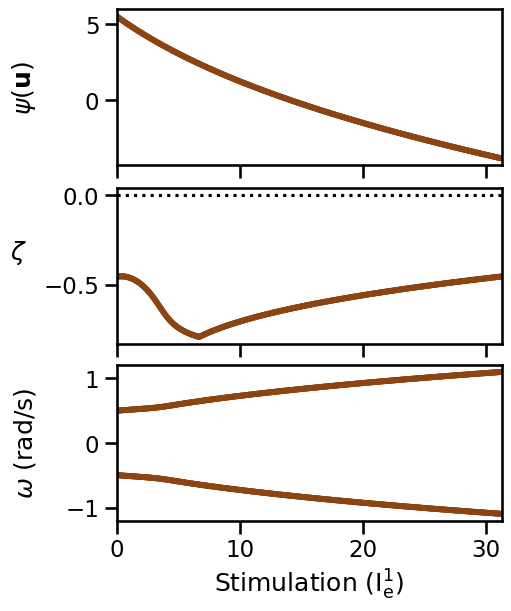

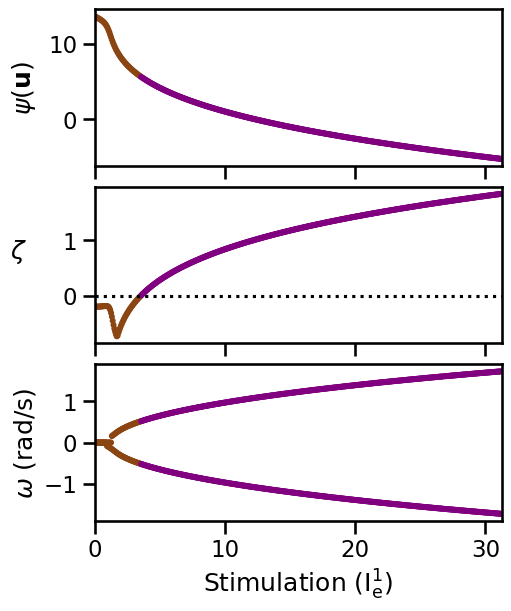

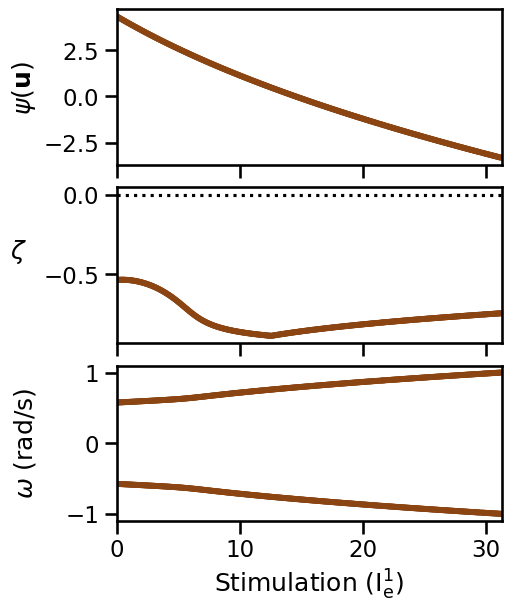

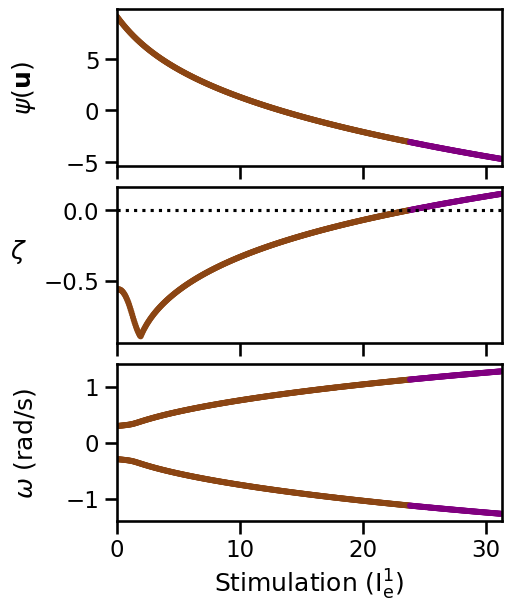

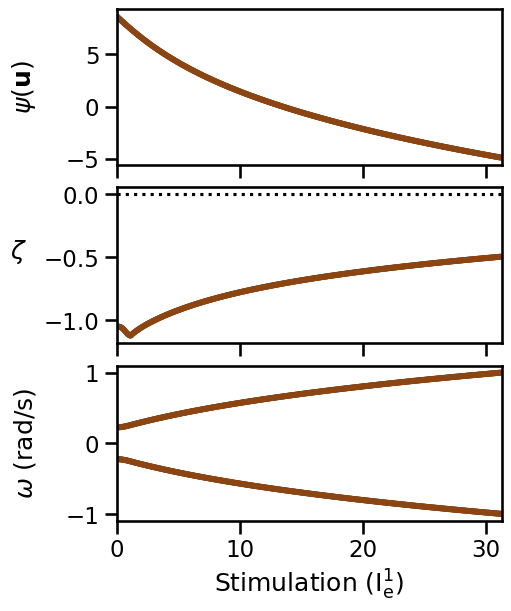

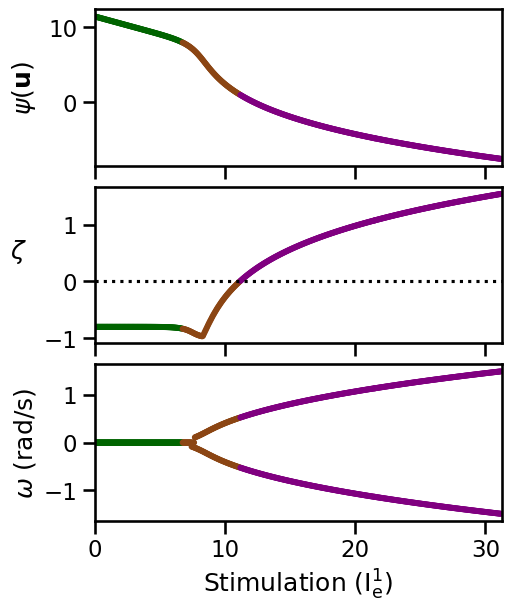

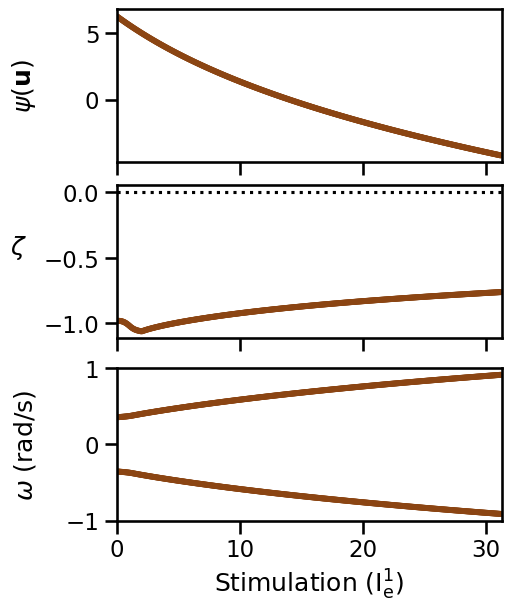

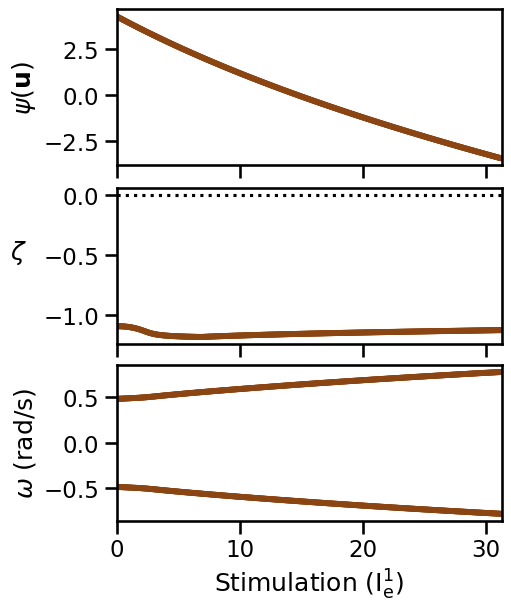

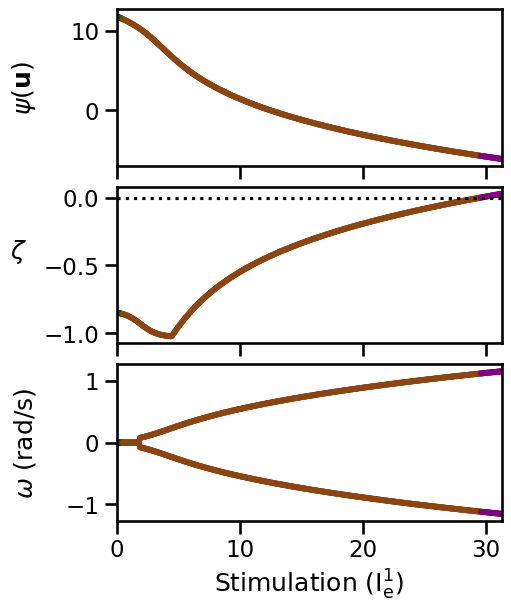

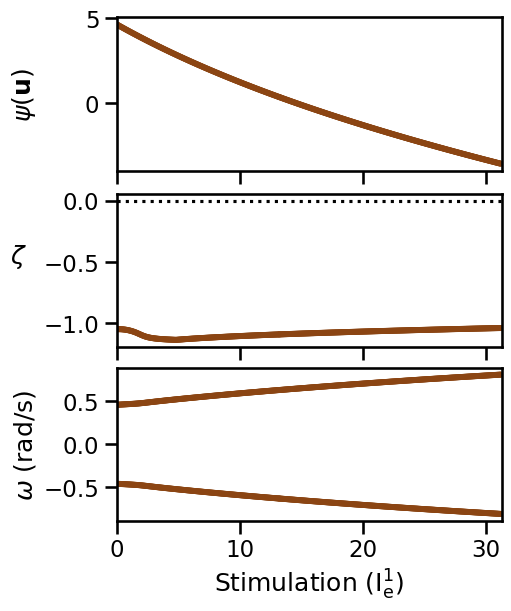

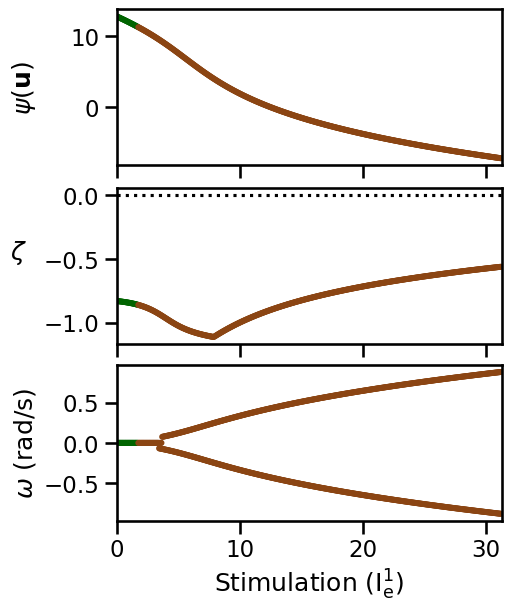

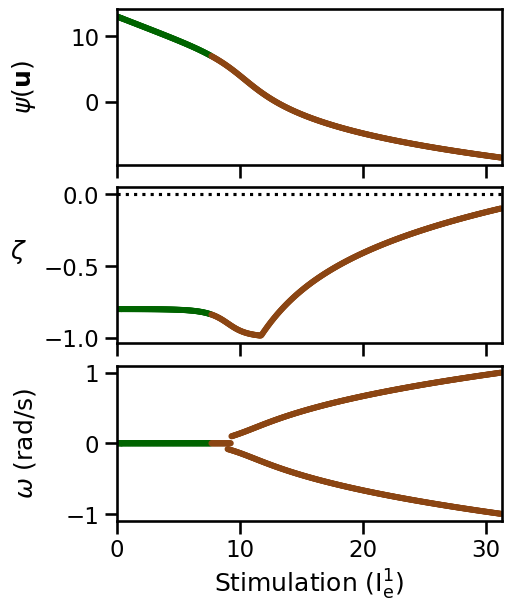

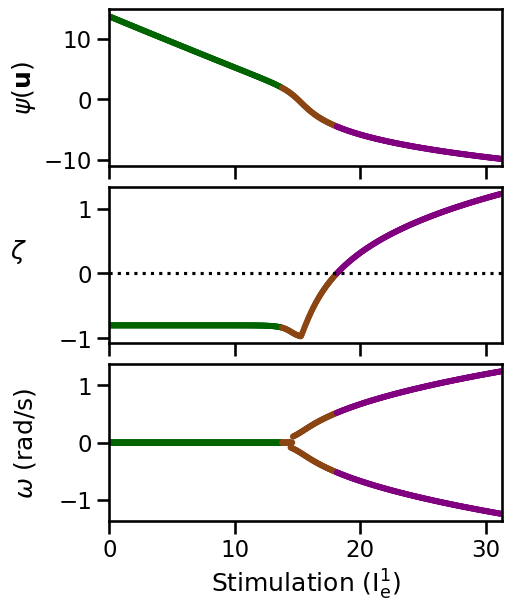

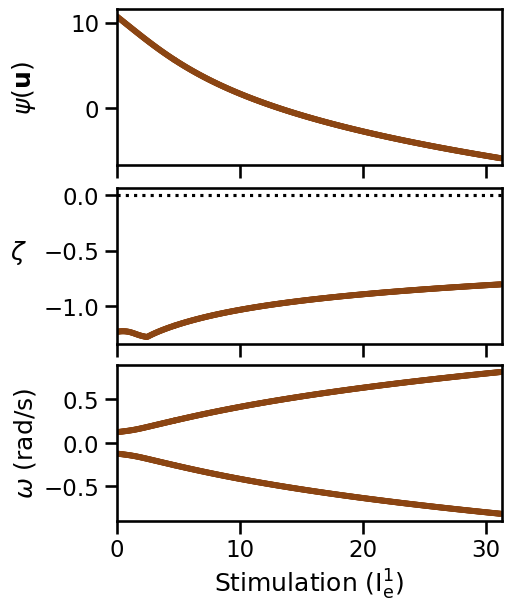

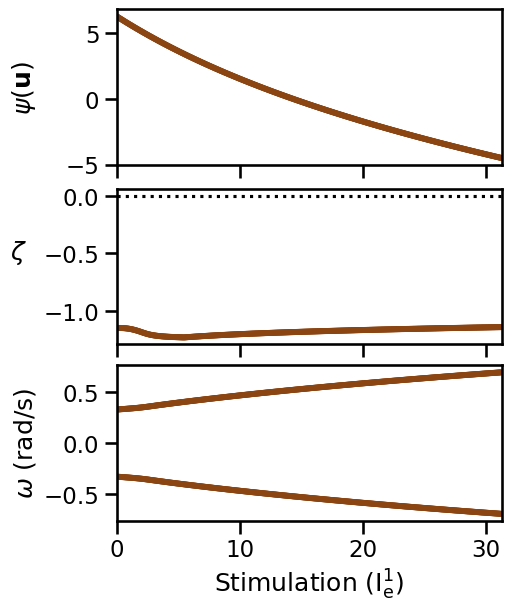

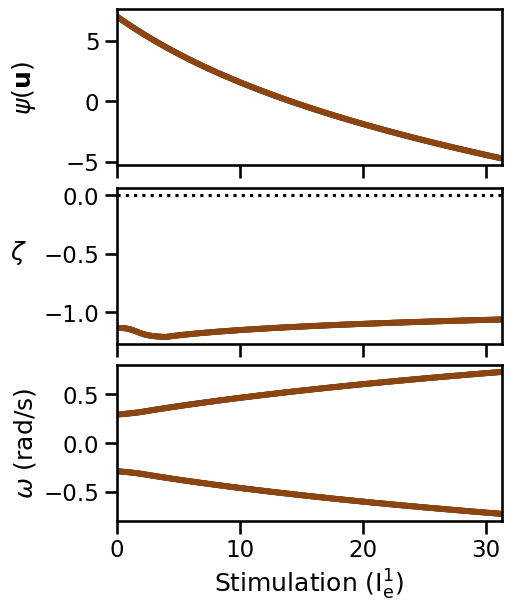

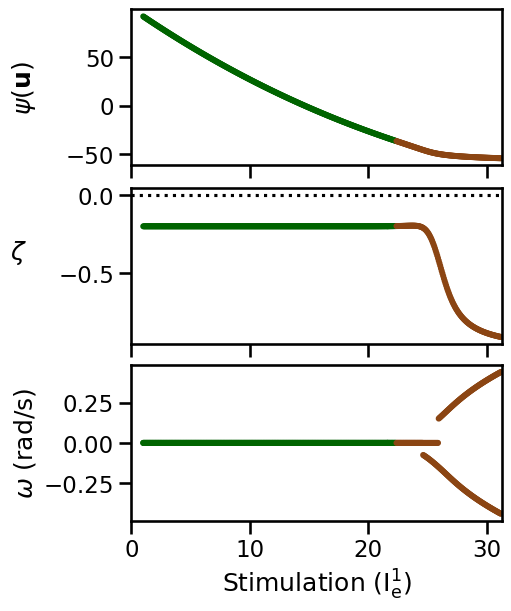

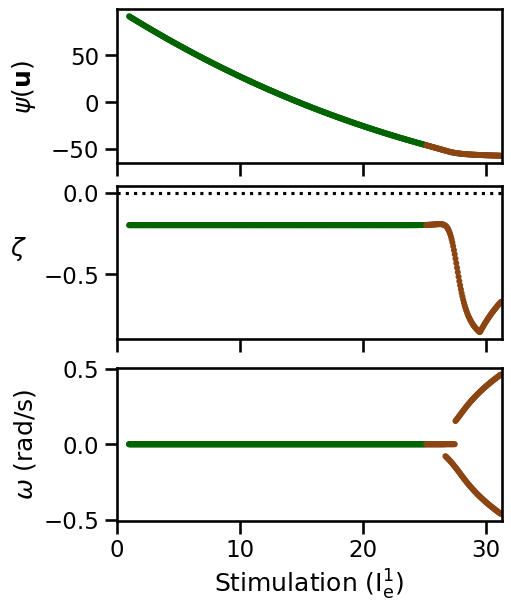

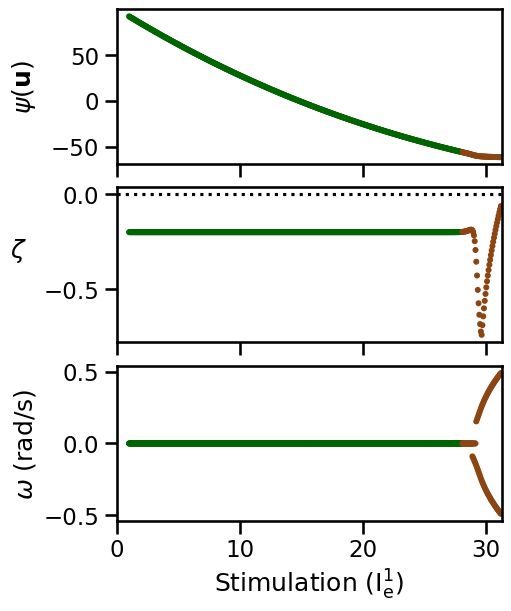

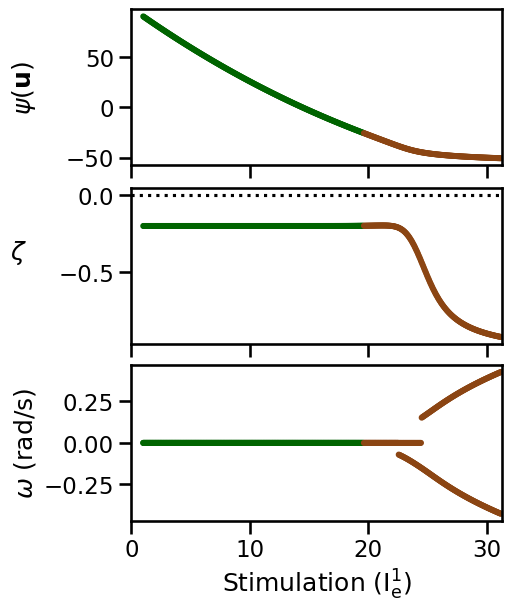

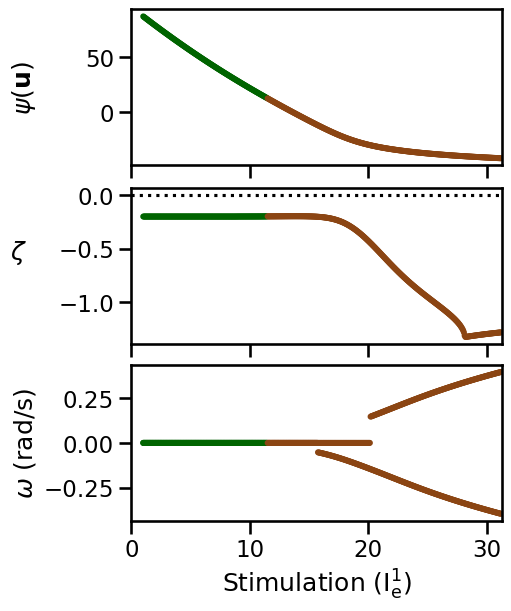

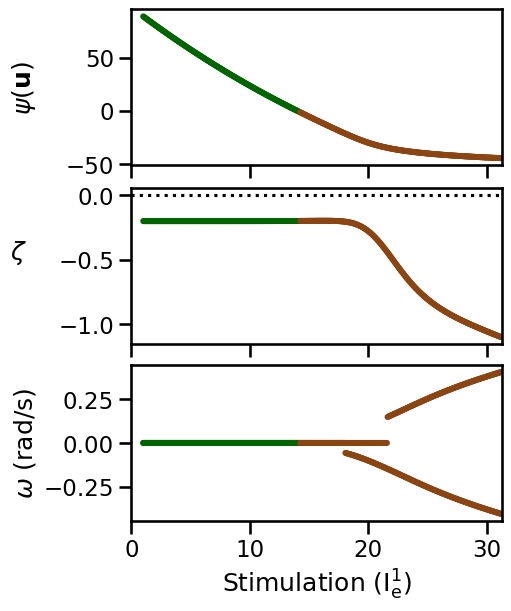

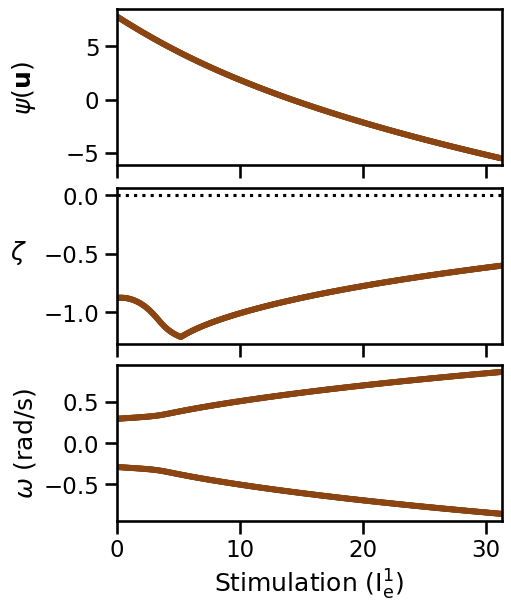

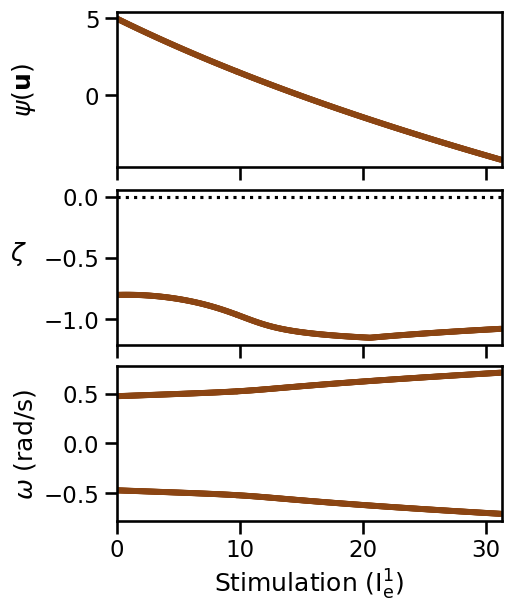

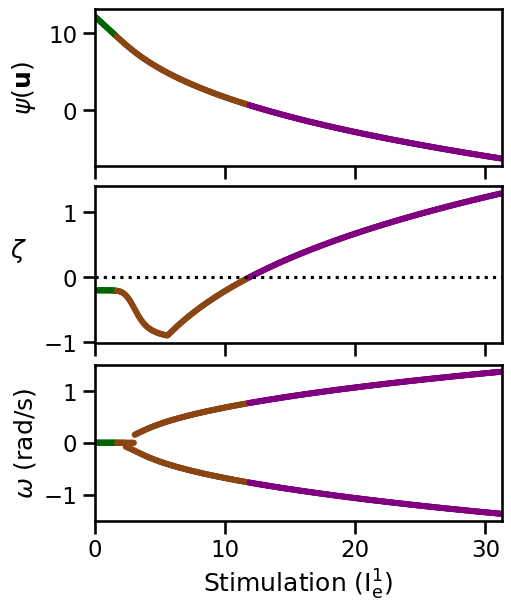

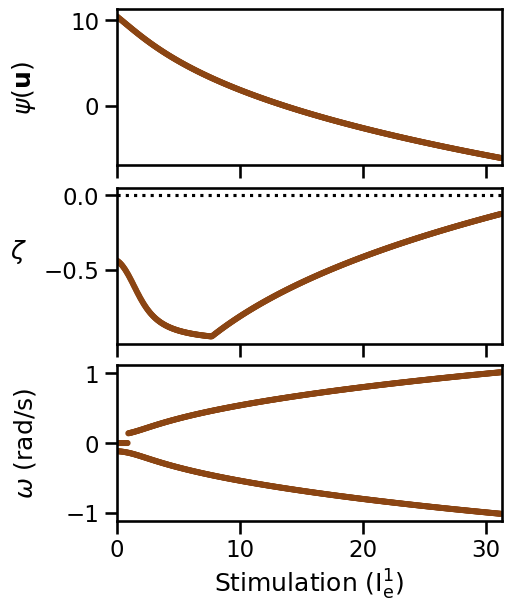

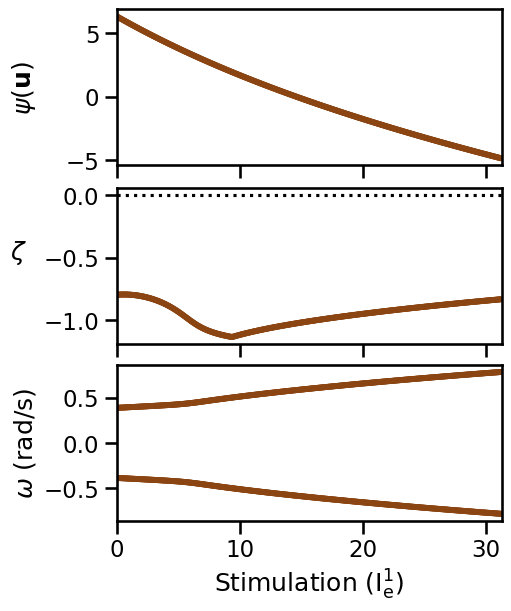

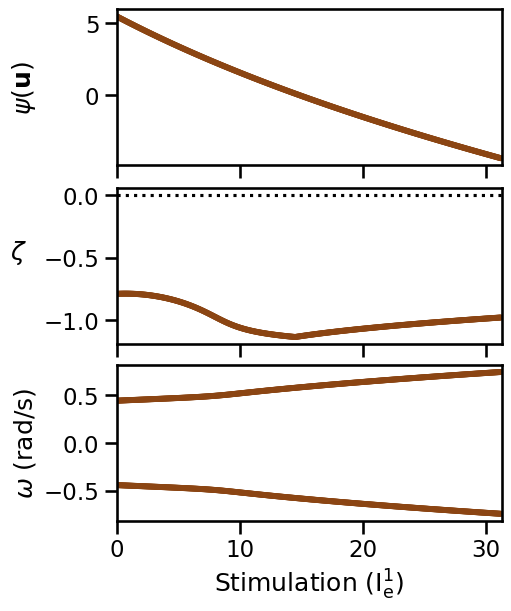

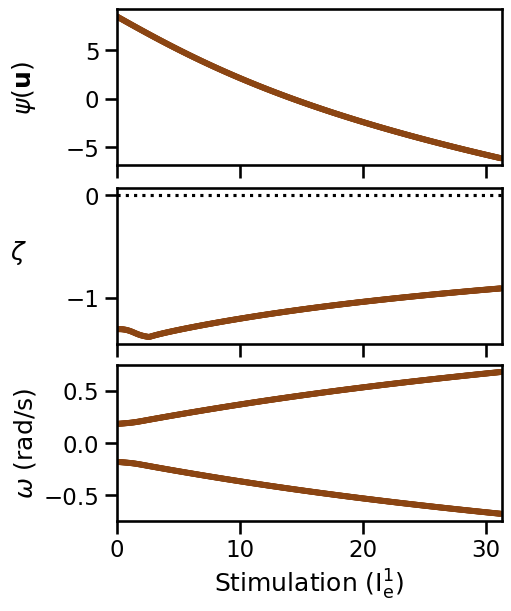

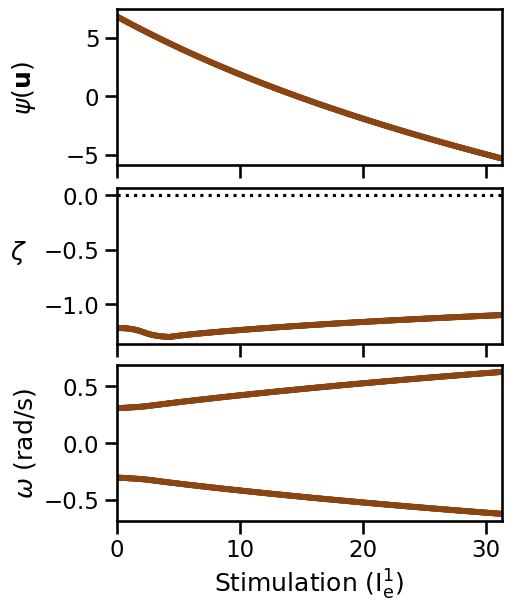

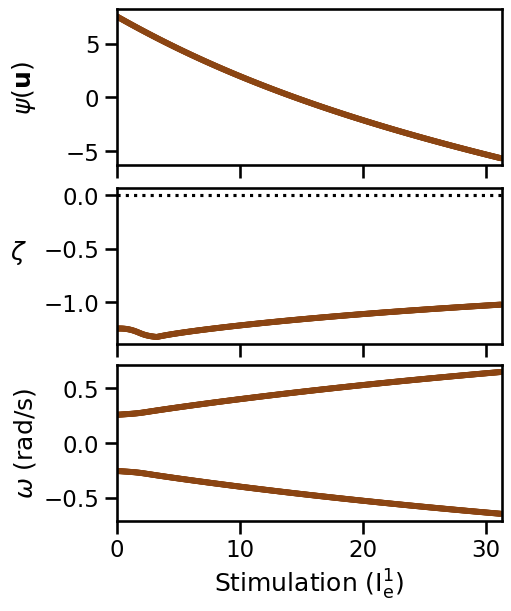

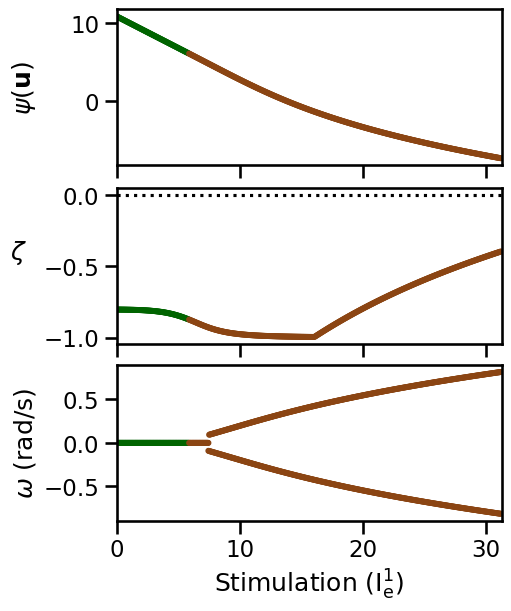

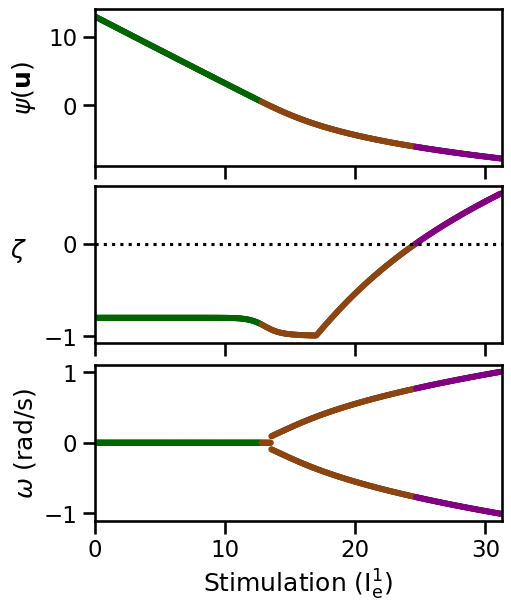

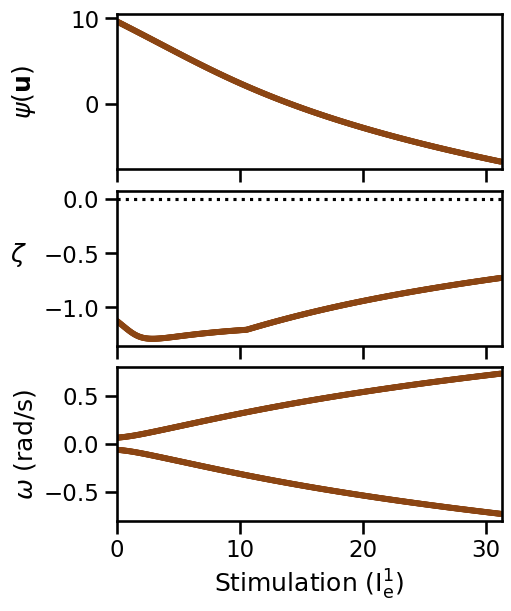

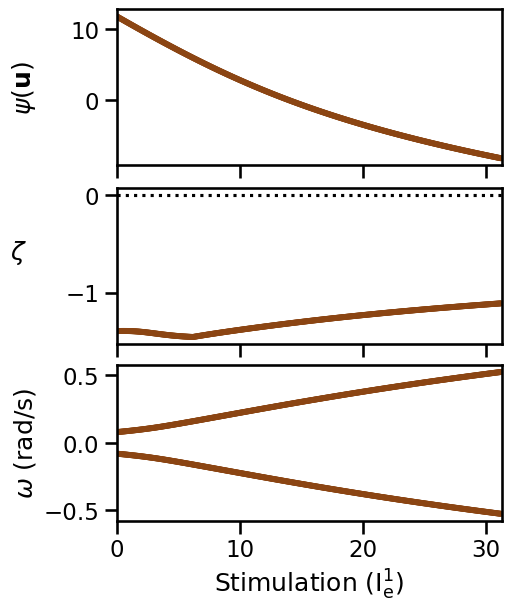

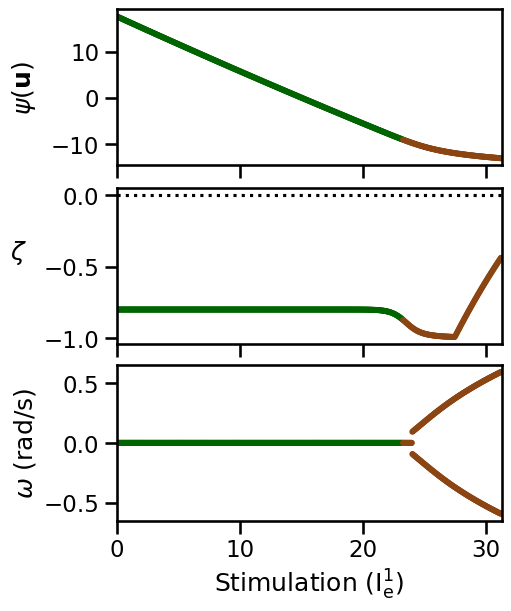

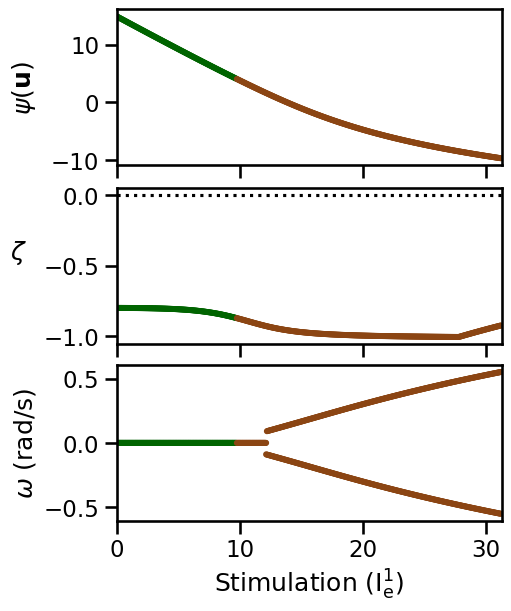

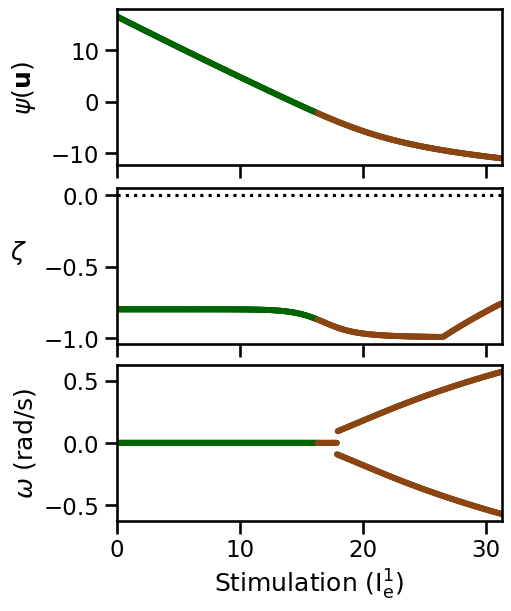

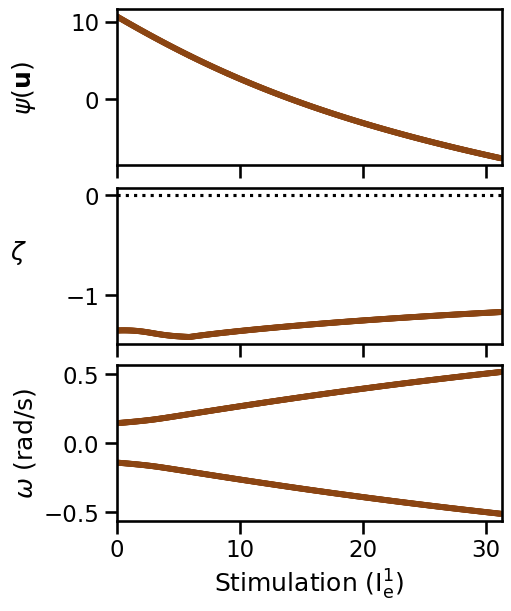

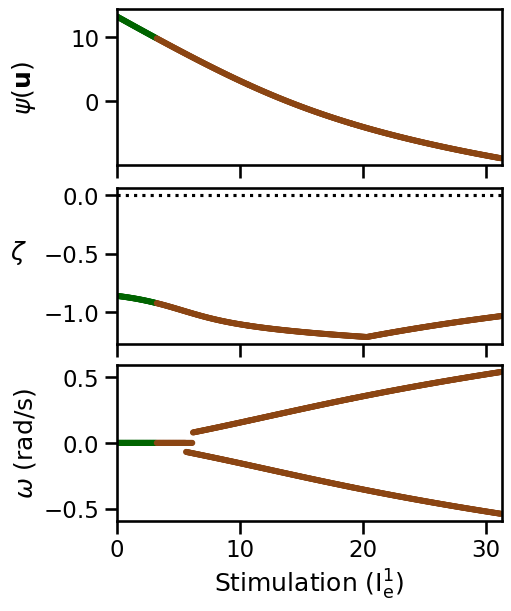

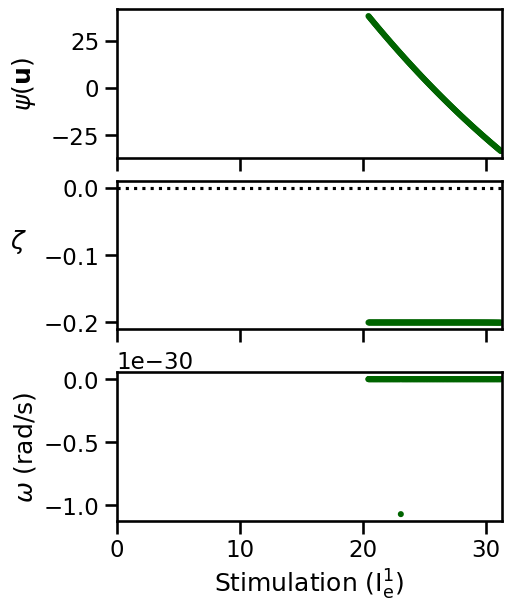

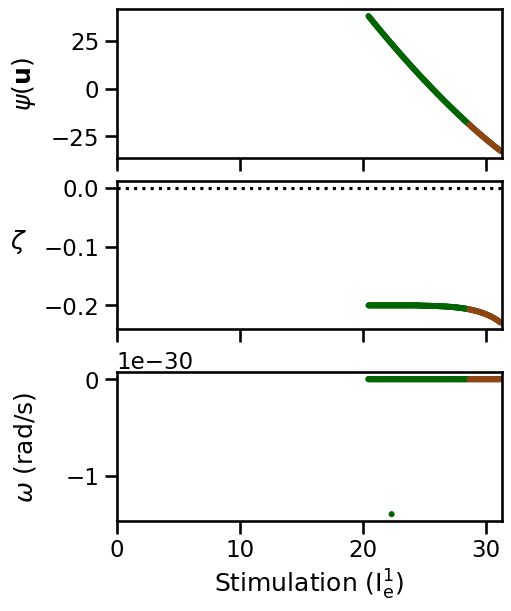

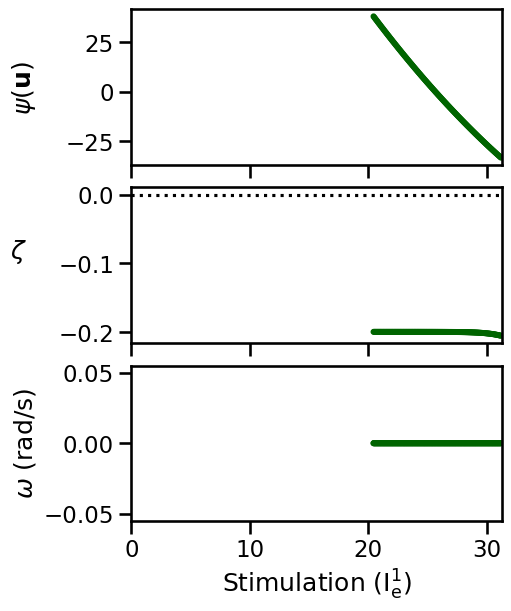

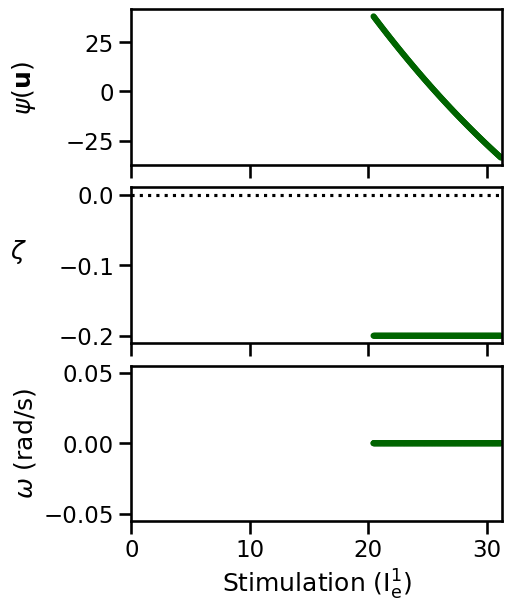

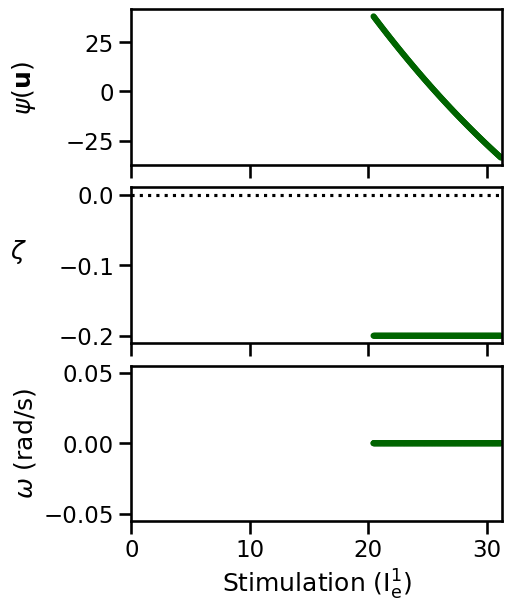

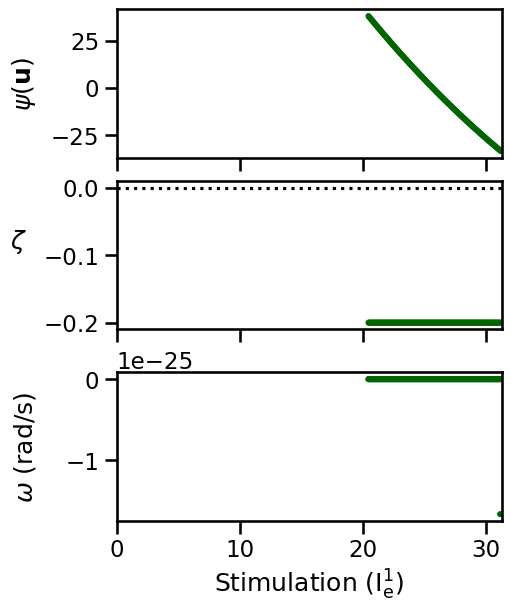

In [21]:
sigiValues = [5, 12.5, 17.5]

for filePath in filePathsSort:
    BaseName = os.path.basename(filePath).split('.pkl')[0]
    K = float(BaseName.split('_')[-1])
    Sige = float(BaseName.split('_')[3])
    Sigi = float(BaseName.split('_')[4])

    if K not in [-0.8, -0.2, 0.2, 0.8]:
        continue
 
    if Sigi not in sigiValues:
        continue
    
    with open(filePath, 'rb') as file_:
        DataDict = pickle.load(file_)
    
    params['sig_e1'] = params['sig_e2'] = Sige
    params['sig_i1'] = params['sig_i2'] = Sigi
    params['K'] = K
    
    plot_dict = {'fig_size': (10, 8), 'xlabel': r"$I^1_e$", 'var_name': 'external stimulus'}
    file_str_k = f"K_{K:.3f}_sige_{Sige:.3f}_sigi_{Sigi:.3f}.jpg"

    fpList = []
    for _, fps in DataDict['fps'].items():
        fpList.append(fps)
    
    fpList = np.array(fpList)
    eig_dict = calc_jacobian(fpList.T, **params)

    eigVals = eig_dict['eigvals']

    I = np.array(DataDict['fp_var']) - params['i_e2']

    decayRates = []
    OscilRate1 = []
    OscilRate2 = []

    for ne, eigSpectrum in enumerate(eigVals):
        signifOrder = np.argsort(eigSpectrum.real)[::-1]
        decayRate = eigSpectrum[signifOrder][0].real

        spectMean = np.mean(eigSpectrum)
        signifOrder = np.argsort(np.abs(eigSpectrum-spectMean))[::-1]
        Omega = eigSpectrum[signifOrder][:2].imag / (2 * np.pi)

        # adjutsment
        imag_ = eigSpectrum[signifOrder].imag
        imag_ = np.round(imag_, 1)
        if (imag_ == 0).all():
            if DataDict['fp_types']['ue1'][ne] == 'purple':
                DataDict['fp_types']['ue1'][ne] = 'red'
                DataDict['fp_types']['ui1'][ne] = 'red'
                DataDict['fp_types']['ue2'][ne] = 'red'
                DataDict['fp_types']['ui2'][ne] = 'red'
            
            if DataDict['fp_types']['ue1'][ne] == 'saddlebrown':
                DataDict['fp_types']['ue1'][ne] = 'darkgreen'
                DataDict['fp_types']['ui1'][ne] = 'darkgreen'
                DataDict['fp_types']['ue2'][ne] = 'darkgreen'
                DataDict['fp_types']['ui2'][ne] = 'darkgreen'

        decayRates.append(decayRate)
        OscilRate1.append(Omega[0])
        OscilRate2.append(Omega[1])

    DF = dimreduction(DataDict, xVar='I', **params)

    textDelt = max(DF['U']/ params['gamma']) * 0.5
    fig, axs = plt.subplots(3, 1, figsize=(5, 6), sharex=True, layout='constrained')
    axs[0].scatter(I, DF['U'] / params['gamma'], c=DF['FP_types'], marker='.', s = 32)
    axs[0].set_ylabel(r'$\psi(\mathbf{u})$', fontsize=18)
    # axs[0].text(-5, max(DF['U']/ params['gamma']) + textDelt, COLOR_MAP['purple'], c='purple')
    # axs[0].text(18, max(DF['U']/ params['gamma']) + textDelt, COLOR_MAP['red'], c='red')
    # axs[0].text(18, max(DF['U']/ params['gamma']) + textDelt / 2, COLOR_MAP['black'], c='black')
    # axs[0].text(-5, max(DF['U']/ params['gamma']) + textDelt / 2, COLOR_MAP['mediumblue'], c='mediumblue')

    # axs[0].text(7, max(DF['U']/ params['gamma']) + textDelt / 2, COLOR_MAP['darkgreen'], c='darkgreen')
    # axs[0].text(7, max(DF['U']/ params['gamma']) + textDelt, COLOR_MAP['saddlebrown'], c='saddlebrown')
    

    axs[1].scatter(I, decayRates, marker='.', s = 32, c=DataDict['fp_types']['ue1'])
    axs[1].axhline(y=0, linestyle=':', color='k')
    axs[1].set_xlim(0, 31.25)
    axs[1].set_ylabel(r"$\zeta$", rotation=0, labelpad=18, fontsize=18)

    axs[2].scatter(I, OscilRate1, marker='.', s = 32, c=DataDict['fp_types']['ue1'])
    axs[2].scatter(I, OscilRate2, marker='.', s = 32, c=DataDict['fp_types']['ue1'])
    axs[2].set_ylabel(r'$\omega$ (rad/s)', fontsize=18)
    axs[2].set_xlim(0, 31.25)
    axs[2].set_xlabel(r"Stimulation $(\rm I^1_e)$", fontsize=18)

    fig.align_ylabels() 

    plt.savefig(os.path.join(figureroot, file_str_k), dpi=300, bbox_inches='tight')

In [19]:
# Multi-region summarization
load_dir = "../system_02/results/fp/"
load_str = datetime.datetime(2023, 12, 15)
sub_dir = f"exp-{load_str.year}-{load_str.month}-{load_str.day}"

results_dir = os.path.join(load_dir, sub_dir)
file_paths = glob.glob(os.path.join(results_dir, '*.pkl'))
print(f"Total no. of files = {len(file_paths)}")

file_name = f'scene02_data.pkl'


Total no. of files = 3


In [9]:
with open(os.path.join(results_dir, file_name), 'rb') as file_:
    fp_data = pickle.load(file_)

fp_df = pd.DataFrame.from_dict(fp_data)

In [10]:
I_uniq = fp_df['I'].unique()
sigmae_uniq = fp_df['sig_e'].unique()
sigmai_uniq = fp_df['sig_i'].unique()
K_uniq = fp_df['K'].unique()

nIvals = len(I_uniq)
nSigEvals = len(sigmae_uniq)
nSigIvals = len(sigmai_uniq)
nKvals = len(K_uniq)

print(f"Unique I's = {nIvals} | sigma_e's = {nSigEvals} | sigma_i's = {nSigIvals} | K's = {nKvals}")

Unique I's = 50 | sigma_e's = 50 | sigma_i's = 50 | K's = 50


In [11]:
## Calculate the multi-stability region as delta K vs. sigma for different I values

fileName = 'MultiStable_DeltaI.pkl'

if os.path.isfile(os.path.join(results_dir, fileName)):
    print("File FOUND!")
    with open(os.path.join(results_dir, fileName), 'rb') as f:
        ResultsDict = pickle.load(f)
    
    deltaI_arr = ResultsDict['DeltaI']
    MultiI = ResultsDict['MultiI']

else:

    deltaI_arr = np.zeros((nKvals, nSigEvals, nSigIvals))   # region width in terms of K
    MultiI = np.zeros((nKvals, nSigEvals, nSigIvals))       # no. of multi-stability regions

    for nK in range (0, nKvals):
        K = K_uniq[nK]

        if nK % 10 == 0:
            print(f'Evaluating multi-region width for K = {K:.3f}')
        for nSE, sigE in enumerate(sigmae_uniq):
            for nSI, sigI in enumerate(sigmai_uniq):
            
                df_sub = fp_df[(fp_df['sig_e'] == sigE) & (fp_df['sig_i'] == sigI) & (fp_df['K'] == K)]

                fp_counts_dict = df_sub['I'].value_counts().sort_index().to_dict()

                I = np.array(list(fp_counts_dict.keys()))
                Isort = np.argsort(I)
                I = I[Isort]

                FP_count = np.array(list(fp_counts_dict.values()))
                FP_count = FP_count[Isort]

                MultiR_id = np.where(FP_count > 1)[0]

                if len(MultiR_id) == 0:
                    continue

                Mult_diffid = np.diff(MultiR_id)

                markers = np.where(Mult_diffid > 5)[0] + 1
                nRegions = len(markers)

                # if there are multiple multi-stable regions in the system delta K is claculated as sum of delta K over all regions
                if nRegions:
                    segment_delt = []
                    start_marker = 0

                    for i in range(nRegions + 1):
                        if i !=  nRegions:
                            marker = markers[i]
                            segment = MultiR_id[start_marker:marker]
                        else:
                            segment = MultiR_id[start_marker:]
                        
                        if i < nRegions:
                            start_marker = marker

                        segment_delt.append(I[segment[-1]] - I[segment[0]]) if len(segment) > 0 else 0
                    
                    deltaI_arr[nK, nSE, nSI] = sum(segment_delt)
                    MultiI[nK, nSE, nSI] = len(segment_delt)

                else:
                    MultiI[nK, nSE, nSI] += 1
                    deltaI_arr[nK, nSE, nSI] = I[MultiR_id[-1]] - I[MultiR_id[0]]

    ResultsDict = {
                    'DeltaI': deltaI_arr,
                    'MultiI': MultiI
                }
    
    with open(os.path.join(load_dir, fileName), 'wb') as f:
        pickle.dump(ResultsDict, f)     

File FOUND!


In [12]:
def smooth(y, nWindow, polyOrder=2):
    y_smooth = sp.signal.savgol_filter(y, nWindow, polyOrder, mode='nearest')
    return y_smooth

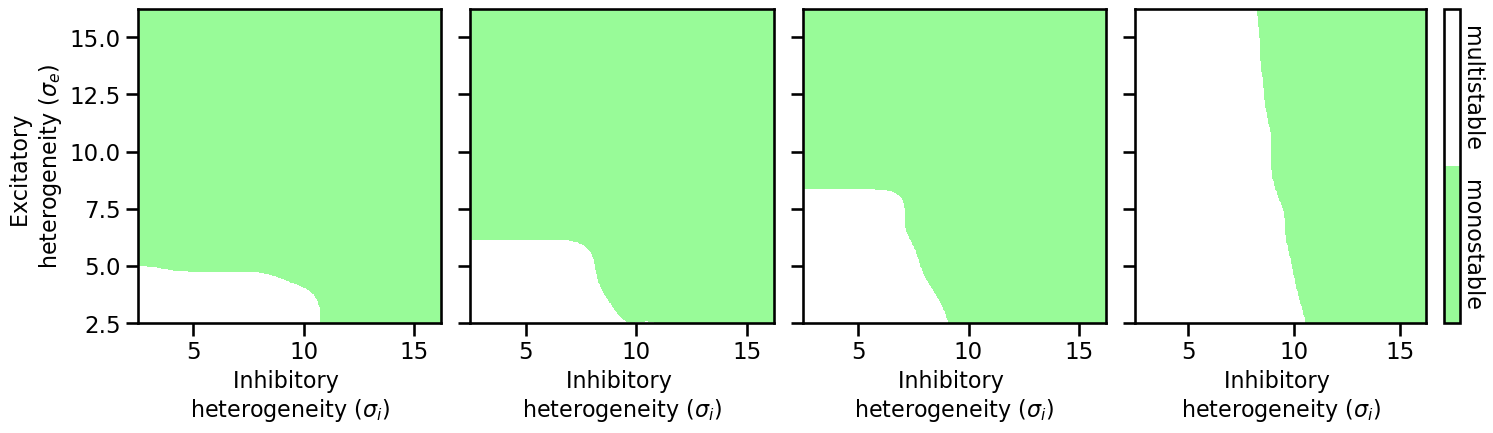

In [13]:
fileName = 'MultiStable_DeltaI_HeatMap.jpg'

smoothDeltI = deepcopy(deltaI_arr)

for nK in range(nKvals):
    for nSE in range(nSigEvals):
        smoothDeltI[nK, nSE, :] = smooth(smoothDeltI[nK, nSE, :], nWindow=7, polyOrder=3)

encodeDeltaI = deepcopy(smoothDeltI)
encodeDeltaI[encodeDeltaI > 0.000] = 1
encodeDeltaI[encodeDeltaI <= 0.000] = 0

fig, axs = plt.subplots(1, 4, figsize=(15, 4.5), sharey=True, gridspec_kw={'width_ratios':[1,1,1,1.2]})

nRow = 0
nCol = 0

LETTER = 'ABCD'
kInd = np.array([5, 20, 30, 45])
for nK in kInd:
    response = deepcopy(encodeDeltaI[nK, :, :])
    mask = response == np.inf 
    response[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), response[~mask])

    y, x, r = cv_upsample(orig_response=response, eval_arrx=sigmai_uniq, eval_arry=sigmae_uniq, 
                                y_max=max(sigmae_uniq), y_min=min(sigmae_uniq), x_max=max(sigmai_uniq), x_min=min(sigmai_uniq),
                                sigma_x = 25, sigma_y = 25,  resolution = 500     ) 
    
    pcos = axs[nCol].pcolormesh(x, y, r, cmap=ListedColormap(['palegreen', 'white']))
    axs[nCol].set_xlabel(f"Inhibitory \nheterogeneity " + r"$(\sigma_i)$", fontsize=16)
    axs[nCol].set_xlim(2.5, max(x))

    if nCol == 0:
        axs[nCol].set_ylabel("Excitatory \nheterogeneity " + r"$(\sigma_e)$", fontsize=16)
        axs[nCol].set_ylim(2.5, max(y))
    nCol += 1
    # axs[nRow, nCol].text(8, 10 , r"$K_{glob} = $" + f"{K_uniq[nK]:.2f}", fontsize=16)

cbar = fig.colorbar(pcos, ax=axs[3], location='right', pad=0.05)
cbar.ax.get_yaxis().set_ticks([])
cbar.ax.text(1.75, -.5 , r"monostable", rotation=270, ha='center', va='center', fontsize=16)
cbar.ax.text(1.75, .5 , r"multistable", rotation=270, ha='center', va='center', fontsize=16)

plt.tight_layout()
plt.savefig(os.path.join(figureroot, fileName), dpi=300)
plt.show()